# Visual Data Science Notebook on Renewable Energy Insight
This notebook helps to work through the pipeline of getting interesting information and metrics on renewable energies

## Return on investment of different countries

In [56]:

import sys
print(sys.executable)
import pandas as pd
import numpy as np
import chardet
import seaborn as snus
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from enum import Enum   
DATA_FOLDER = "data/"
SELECTED_COUNTRIES = ["Austria", "Belgium", "Canada", "Czechia", "Denmark", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Japan", "Korea", "Latvia",
    "Luxembourg", "Mexico", "New Zealand", "Norway", "Poland", "Portugal",
    "Slovak Republic", "Spain", "Sweden", "Switzerland", "The Netherlands",
    "Türkiye", "United Kingdom", "United States"]#["Poland","France", "Japan","Denmark", "Switzerland", "Poland","Austria","Sweden"] #"Italy", "Spain", "United Kingdom", "Netherlands", "Sweden" #"Germany","Mexico", "Brazil","Austria", "France", "Türkiye", "Japan", "Egypt","Korea", "United States","Portugal", "Australia","Poland" 
IAE_MEMBERS = [
    "Australia", "Austria", "Belgium", "Canada", "Czechia", "Denmark",
    "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Japan", "Korea", "Latvia", "Lithuania",
    "Luxembourg", "Mexico", "New Zealand", "Norway", "Poland", "Portugal",
    "Slovak Republic", "Spain", "Sweden", "Switzerland", "The Netherlands",
    "Türkiye", "United Kingdom", "United States"
]
IAE_ACCESSION = [
    "Chile", "Colombia", "Costa Rica", "Israel"
]
IAE_ASSOCIATION = [
    # "Argentina", "Brazil", "China", "Egypt", "India", "Indonesia",
    # "Kenya", "Morocco", "Senegal", "Singapore", "South Africa",
    # "Thailand", "Ukraine"
]
IAE_COMBINED = IAE_MEMBERS + IAE_ACCESSION + IAE_ASSOCIATION

RDD_IMPACT_COUNTRY_SELECTION = ['Denmark','Finnland', 'Germany', 'Ireland', 'Mexico','Norway', 'Sweden', 'Poland']

class RDD_TYPE(Enum):
    TOTAL = "TOTAL"
    RENEWABLE = "RENEWABLE"
    FOSSILFUEL = "FOSSILFUEL"
   
 
COUNTRY_NAME_MAP = {
    ("United States", "United States of America"): "United States",
    ("South Korea", "Korea, Republic of", "Korea, Rep."): "Korea",
    ("Turkey", "Türkiye"): "Türkiye"
}


/home/mozi/miniconda3/envs/vds/bin/python


In [57]:
# with open(DATA_FOLDER + 'capacity-generation-emission.csv', 'rb') as f:
#     result = chardet.detect(f.read())
#     encoding = result['encoding']
capacity_generation_emission_content = pd.read_csv(DATA_FOLDER + "capacity-generation-emission.csv", encoding='utf-8')
#print(capacity_generation_emission_content.head())

gdp_population_content = pd.read_csv(DATA_FOLDER + "gdp-population.csv")

rdd_content = pd.read_csv(DATA_FOLDER + "rdd-total-fossile-renewable.csv")

rdd_renewable_detail_content = pd.read_csv(DATA_FOLDER + "rdd_renewable_detailed.csv")








In [58]:
def uniform_country_names(df, country_column):
    for names, uniform_name in COUNTRY_NAME_MAP.items():
        df[country_column] = df[country_column].replace(names, uniform_name)
    return df

In [59]:

print("Capacity generation emission columns:")
print(capacity_generation_emission_content.columns)
capacity_generation_emission_content = capacity_generation_emission_content.drop(
    columns=[
        "EU","OECD","G7","G20","ASEAN"
        ]
)
capacity_generation_emission_content = capacity_generation_emission_content.rename(columns={"Area": "Country/Region"})
capacity_generation_emission_content = uniform_country_names(capacity_generation_emission_content, "Country/Region")
print("Cleaned capacity generation emission columns:")
print(capacity_generation_emission_content.columns)

print("\n")

print("Public rd&d investment columns:")
print(rdd_content.columns)
rdd_content = rdd_content.drop(
    columns=[
        "STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "ACTION", "COUNTRY", "FREQUENCY", "Frequency",
        "RDD_SECTOR","Technology", "RDD_TYPE","Sector", "Type", "UNIT","Time Period","Observation value", "QUALIFIER", "Qualifier",
        "CONF_STATUS", "Confidential Status", "Decimals","Unit multiplier","DECIMALS"
    ]
)
rdd_content = rdd_content.rename(columns={"RDD_TECH": "Type", "TIME_PERIOD": "Year", "OBS_VALUE": "Investment Amount (Million US$)", "UNIT_MULT": "Unit Multiplier"})
rdd_content = uniform_country_names(rdd_content, "Country/Region")
print("Cleaned public rd&d investment columns:")
print(rdd_content.columns)

print("\n")

print("Gdp and population columns:")
print(gdp_population_content.columns)
#Remove unneeded columns from gdp_population_content
gdp_population_content = gdp_population_content.drop(
    columns=[   
             "Country Code", "Series Code"
    ]
)

#Remove [YRXXXX] from column names
gdp_population_content.columns = gdp_population_content.columns.str.replace(r'\[YR\d{4}\]', '', regex=True).str.strip()
gdp_population_content = pd.melt(gdp_population_content, id_vars=['Country Name', 'Series Name'],value_vars=[col for col in gdp_population_content.columns if col not in ['Country Name', 'Series Name']], var_name='Year', value_name='Value')
gdp_population_content['Value'] = pd.to_numeric(gdp_population_content['Value'], errors='coerce')
gdp_population_content = uniform_country_names(gdp_population_content, "Country Name")
print("Cleaned gdp and population columns:")
print(gdp_population_content.columns)

print("\n")


print("RDD renewable detailed columns:")
print(rdd_renewable_detail_content.columns)
rdd_renewable_detail_content = rdd_renewable_detail_content.drop(
    columns=[
        "STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "ACTION", "COUNTRY", "FREQUENCY", "Frequency",
        "RDD_SECTOR","Technology", "RDD_TYPE","Sector", "Type", "UNIT","Time Period","Observation value", "QUALIFIER", "Qualifier",
        "CONF_STATUS", "Confidential Status", "Decimals","Unit multiplier","DECIMALS"
    ]
)
rdd_renewable_detail_content = rdd_renewable_detail_content.rename(columns={"RDD_TECH": "Type", "TIME_PERIOD": "Year", "OBS_VALUE": "Investment Amount (Million US$)", "UNIT_MULT": "Unit Multiplier"})
rdd_renewable_detail_content = uniform_country_names(rdd_renewable_detail_content, "Country/Region")

print("Cleaned rdd renewable detailed columns:")
print(rdd_renewable_detail_content.columns)

Capacity generation emission columns:
Index(['Area', 'ISO 3 code', 'Year', 'Area type', 'Continent', 'Ember region',
       'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory',
       'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change'],
      dtype='object')
Cleaned capacity generation emission columns:
Index(['Country/Region', 'ISO 3 code', 'Year', 'Area type', 'Continent',
       'Ember region', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value',
       'YoY absolute change', 'YoY % change'],
      dtype='object')


Public rd&d investment columns:
Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'COUNTRY',
       'Country/Region', 'FREQUENCY', 'Frequency', 'RDD_SECTOR', 'Sector',
       'RDD_TECH', 'Technology', 'RDD_TYPE', 'Type', 'UNIT', 'Unit',
       'TIME_PERIOD', 'Time Period', 'OBS_VALUE', 'Observation value',
       'QUALIFIER', 'Qualifier', 'CONF_STATUS', 'Confidential Status',
       'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'D

In [60]:
def show_scatterplot(data, x, y, hue=None, style=None, size=None,
                     title=None, xlabel=None, ylabel=None,
                     fit_line=False):

    plt.figure(figsize=(10, 6))

    df = data.copy()

    if "Country/Region" in df.columns:
        country_col = "Country/Region"
    else:
        country_col = "Country"
    df_sorted = df.sort_values(by=x)
    worst5_idx = df_sorted.head(5).index
    best5_idx  = df_sorted.tail(5).index
    df["Highlight"] = "Other"
    df.loc[worst5_idx, "Highlight"] = df.loc[worst5_idx, country_col]
    df.loc[best5_idx,  "Highlight"] = df.loc[best5_idx,  country_col]

    import seaborn as sns
    all_labels = df["Highlight"].unique().tolist()
    highlight_labels = [lab for lab in all_labels if lab != "Other"]
    colors = sns.color_palette("colorblind", n_colors=len(highlight_labels))

    all_labels = df["Highlight"].unique().tolist()
    highlight_labels = [lab for lab in all_labels if lab != "Other"]

    # Okabe–Ito extended palette (10 colorblind-safe colors)
    okabe_ito_extended = [
        "#000000",  # black
        "#E69F00",  # orange
        "#56B4E9",  # sky blue
        "#009E73",  # bluish green
        "#F0E442",  # yellow
        "#0072B2",  # blue
        "#D55E00",  # vermillion
        "#CC79A7",  # reddish purple
        "#6F4C9B",  # purple
        "#009EBD",  # cyan
    ]

    colors = okabe_ito_extended[:len(highlight_labels)]

    palette = {"Other": "lightgray"}
    for lab, col in zip(highlight_labels, colors):
        palette[lab] = col

    snus.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="Highlight",
        palette=palette,
        style=style,
        size=size,
        sizes=(50, 1000),
        alpha=0.7
    )

    if fit_line:
        import numpy as np
        xs = df[x].astype(float)
        ys = df[y].astype(float)
        m, b = np.polyfit(xs, ys, 1)
        plt.plot(xs, m*xs + b, color='gray', linewidth=2, linestyle='--')

    plt.title(title if title else 'Scatter Plot', fontsize=14)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()





    

def show_bubbleplot(data, x, y, size, hue=None, title=None, xlabel=None, ylabel=None):
    """
    Creates a bubble plot where marker size encodes a numeric variable.
    """
    plt.figure(figsize=(10, 6))

    snus.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        size=size,
        sizes=(50, 800),   # bubble size range
        alpha=0.6,
        edgecolor="black",
        linewidth=0.5
    )

    plt.title(title if title else 'Bubble Plot', fontsize=14)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [61]:
def get_rdd_investment(country_list, type: RDD_TYPE):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = rdd_content[rdd_content['Country/Region']==country]
        rdd_type = country_data[country_data['Type']==type.value]
        country_list_df = pd.concat([country_list_df, rdd_type], ignore_index=True)
    return country_list_df

def get_rdd_investment_sum_last_n_years(country_list, duration_in_years, type: RDD_TYPE):
    df = get_rdd_investment(country_list, type).copy()
    df = df.sort_values(["Country/Region", "Year"])
    df[f"Sum_last_{duration_in_years}_years"] = (
        df.groupby("Country/Region")["Value"]
          .rolling(window=duration_in_years, min_periods=duration_in_years)
          .sum()
          .reset_index(level=0, drop=True)
    )
    df = df.dropna(subset=[f"Sum_last_{duration_in_years}_years"])
    return df



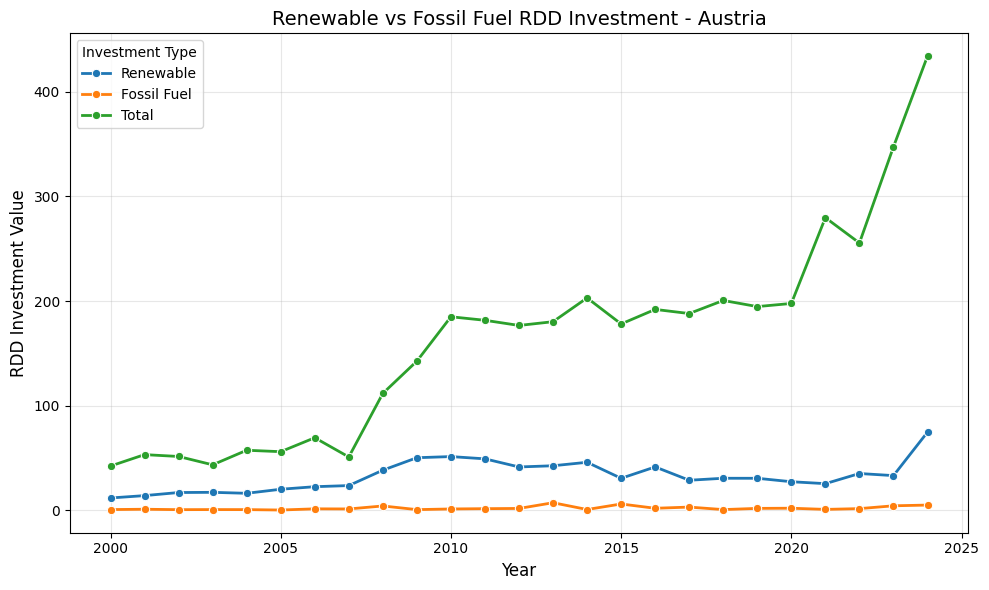

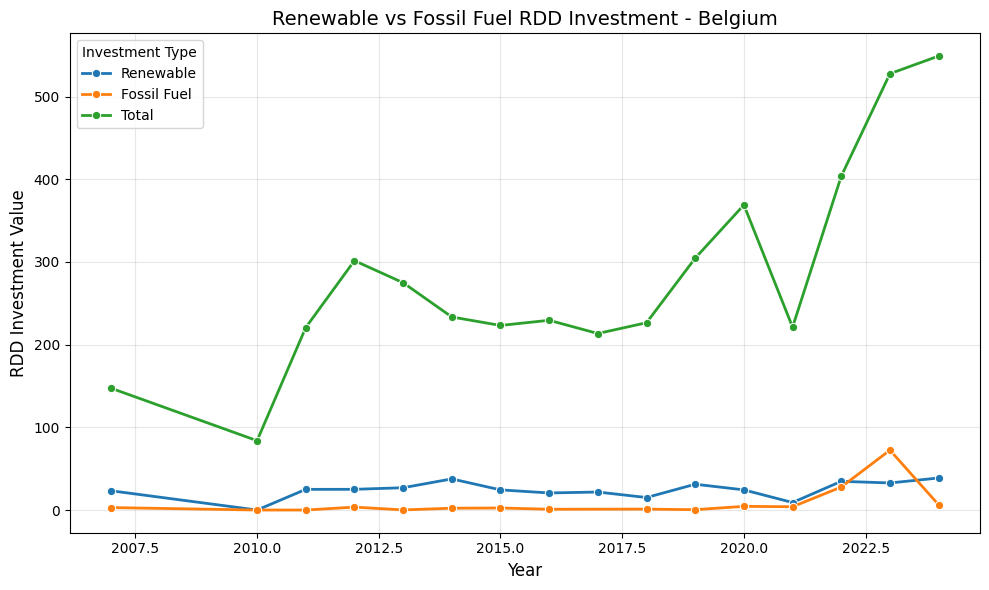

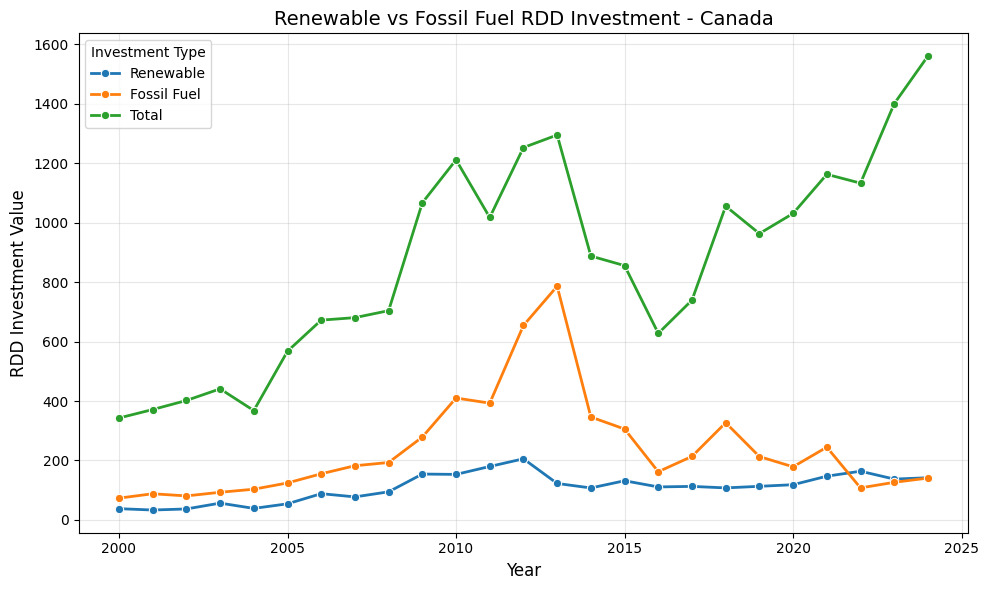

/tmp/ipykernel_282775/2193988868.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Investment Type', loc='best')


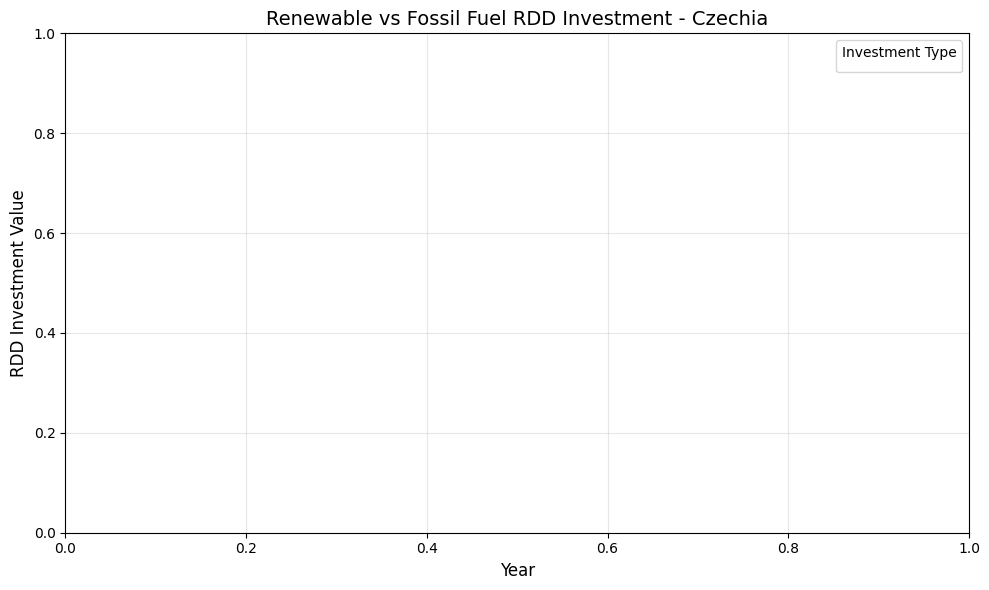

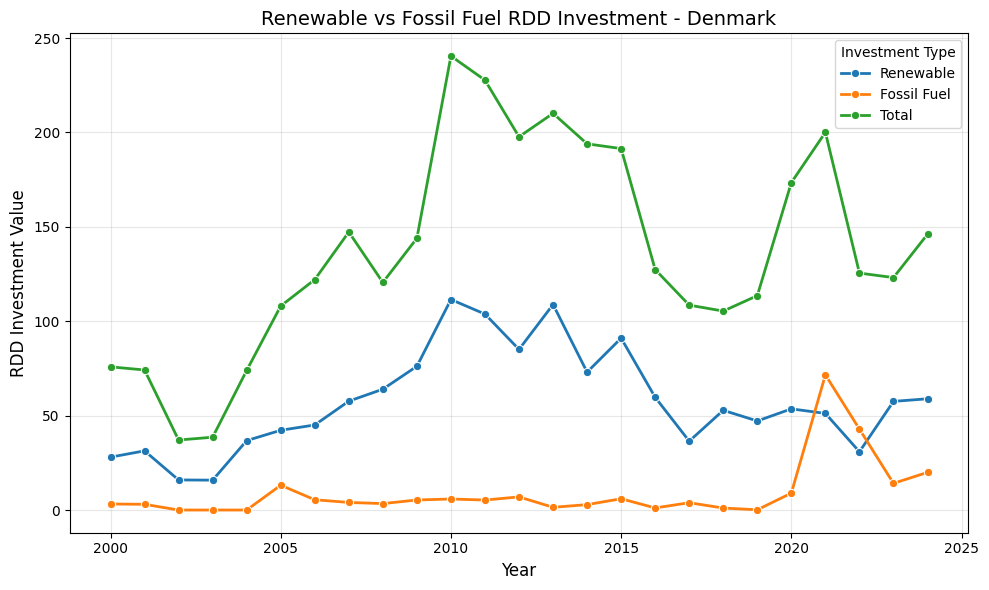

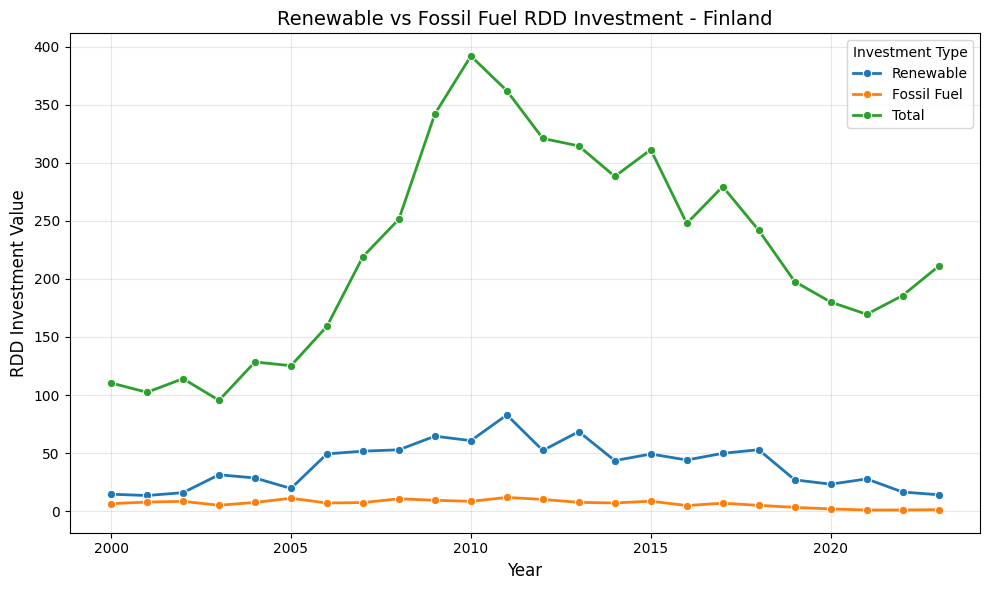

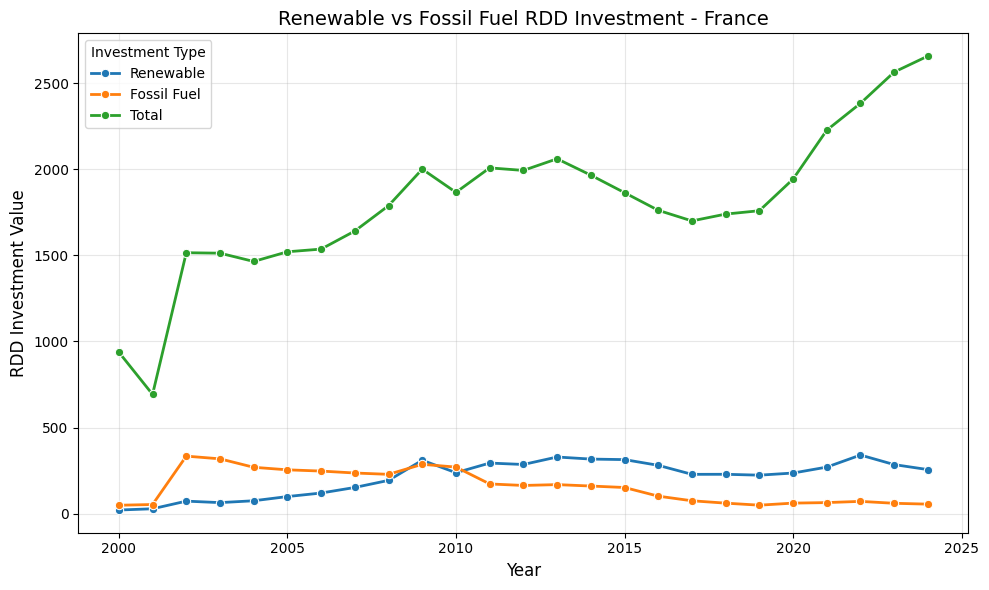

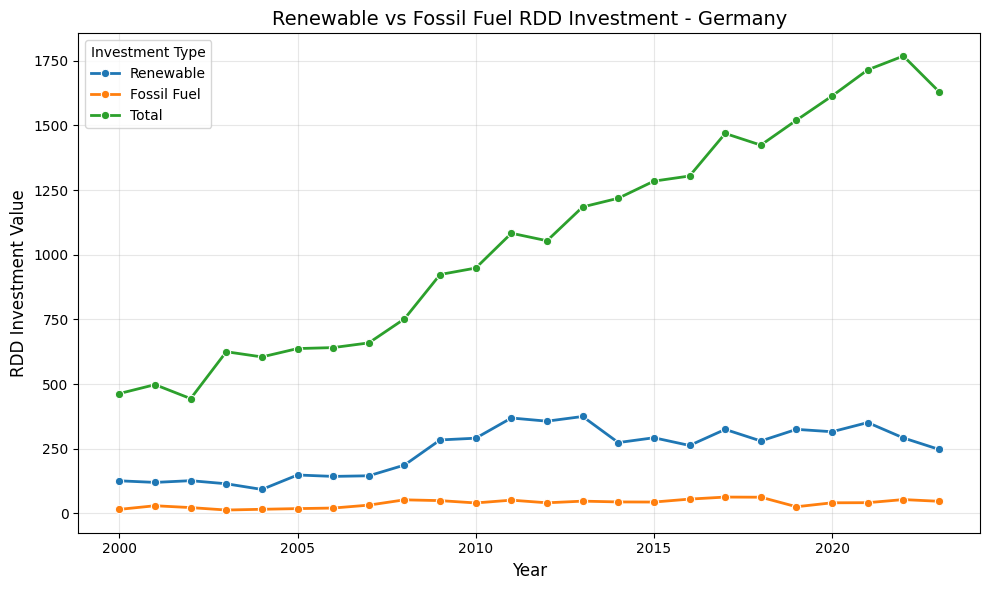

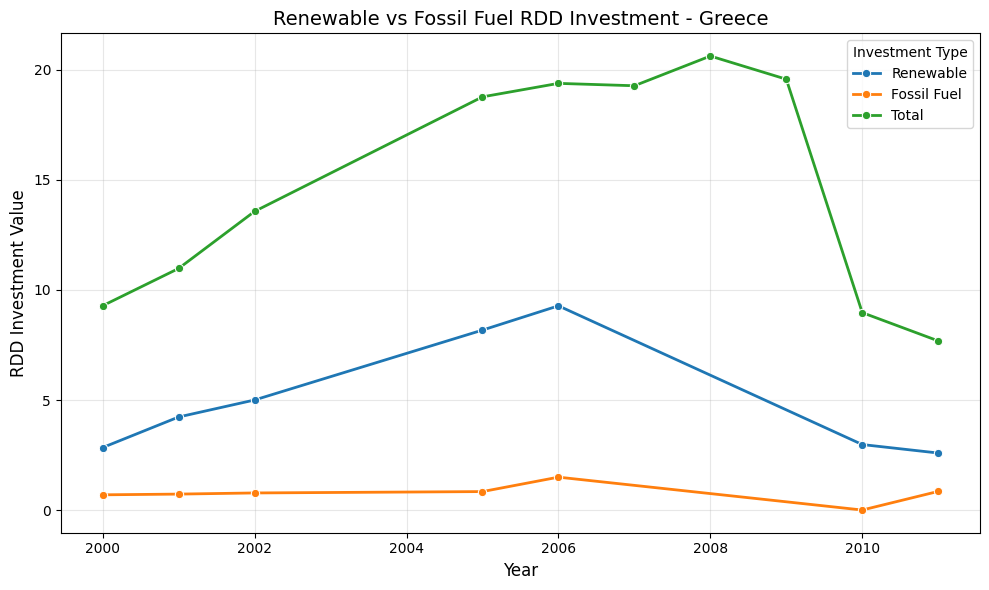

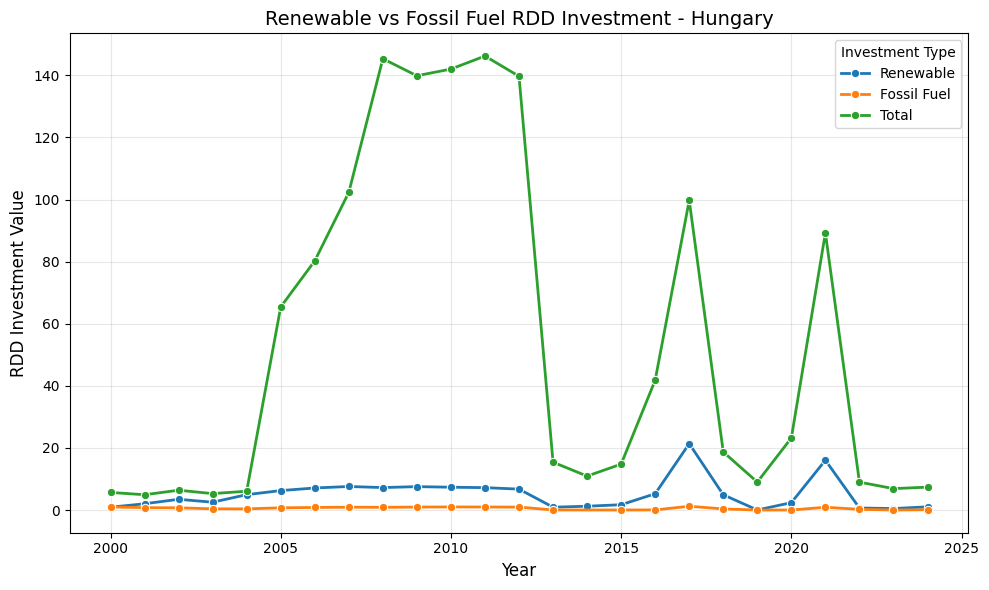

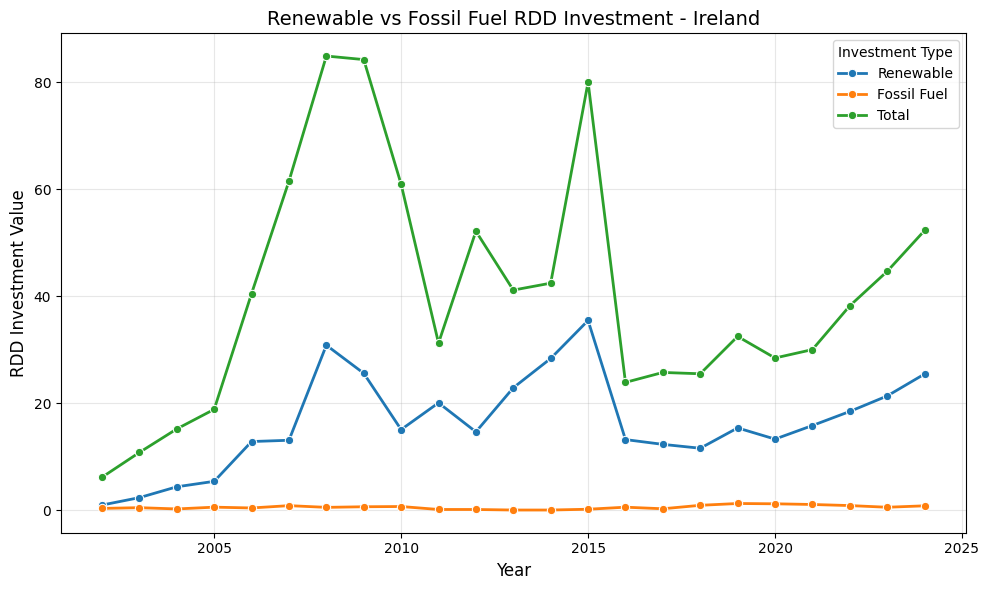

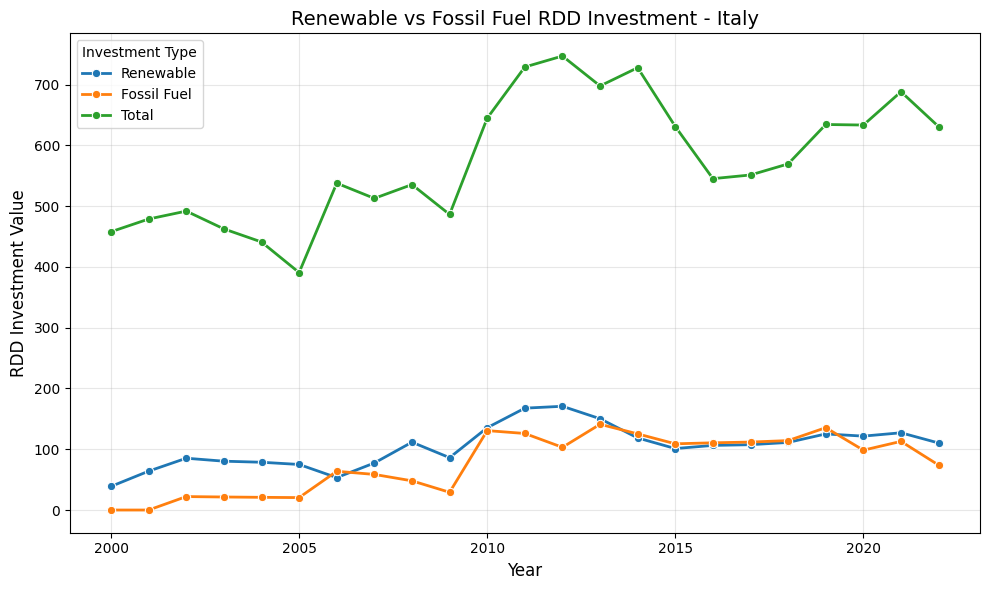

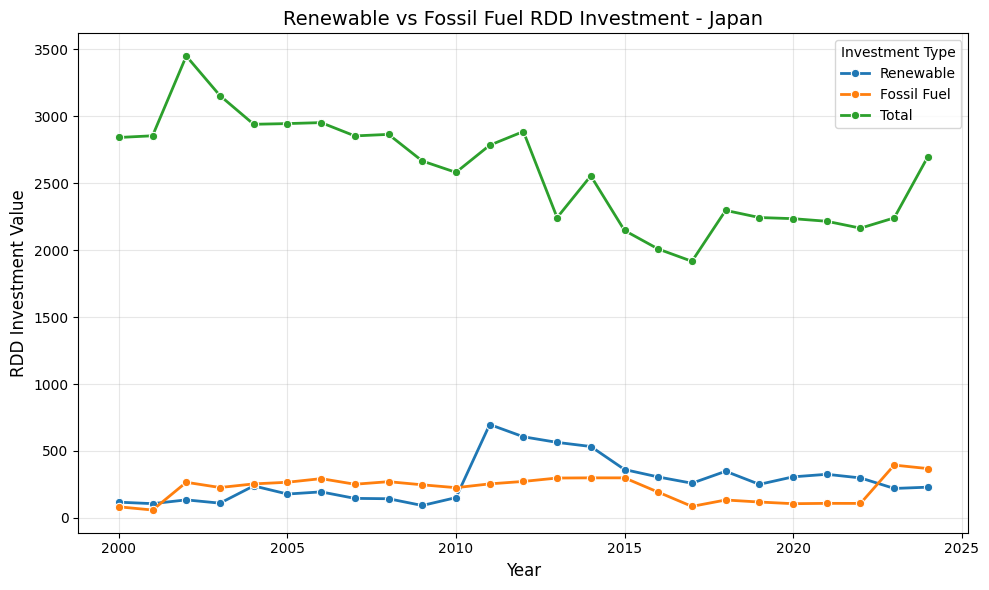

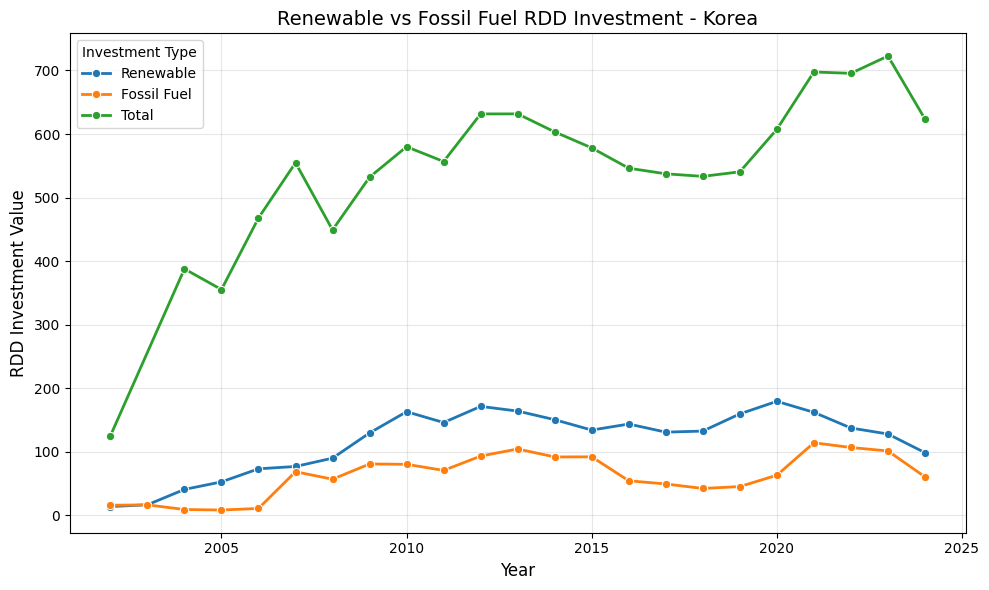

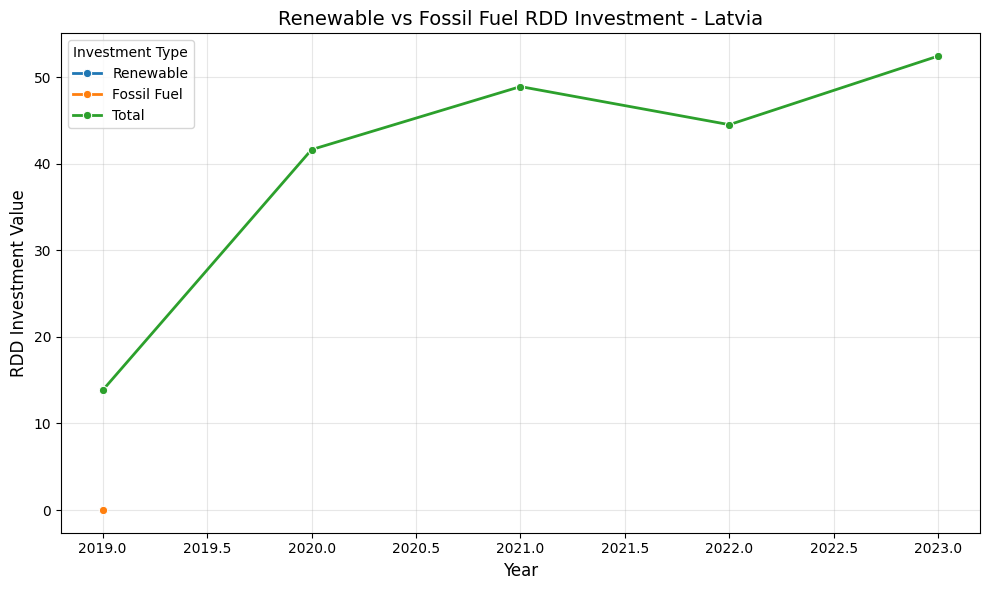

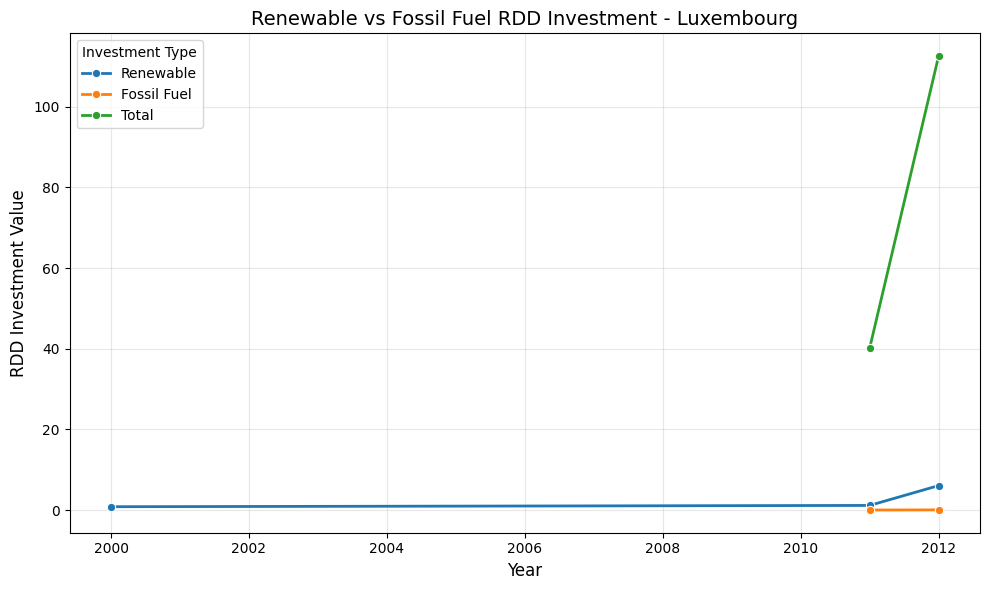

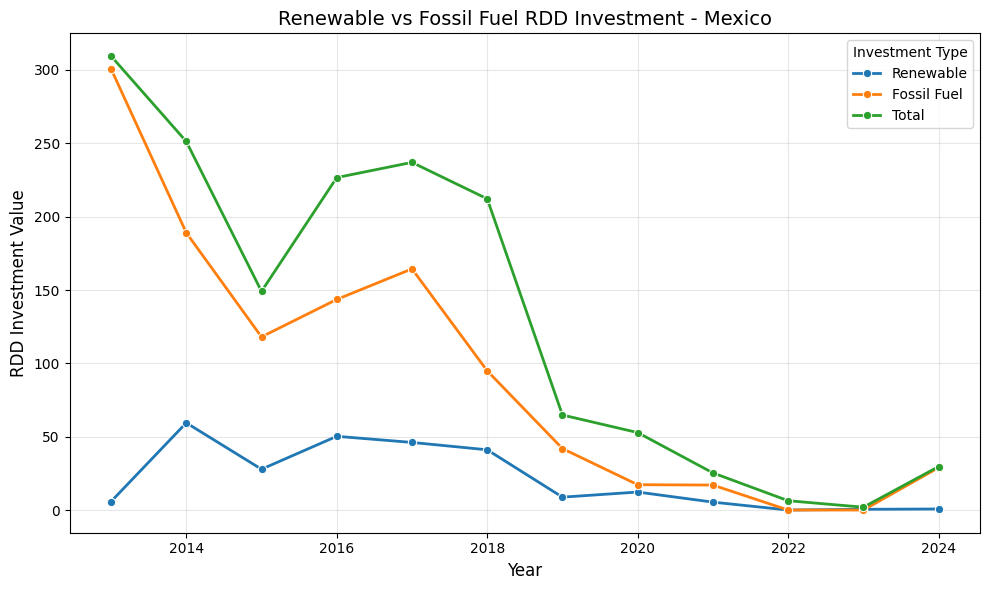

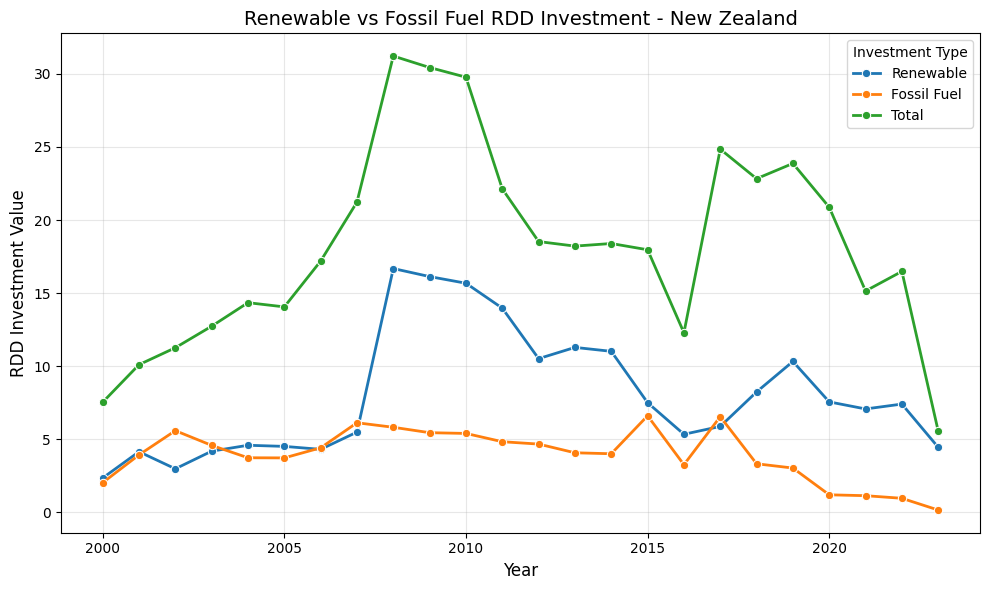

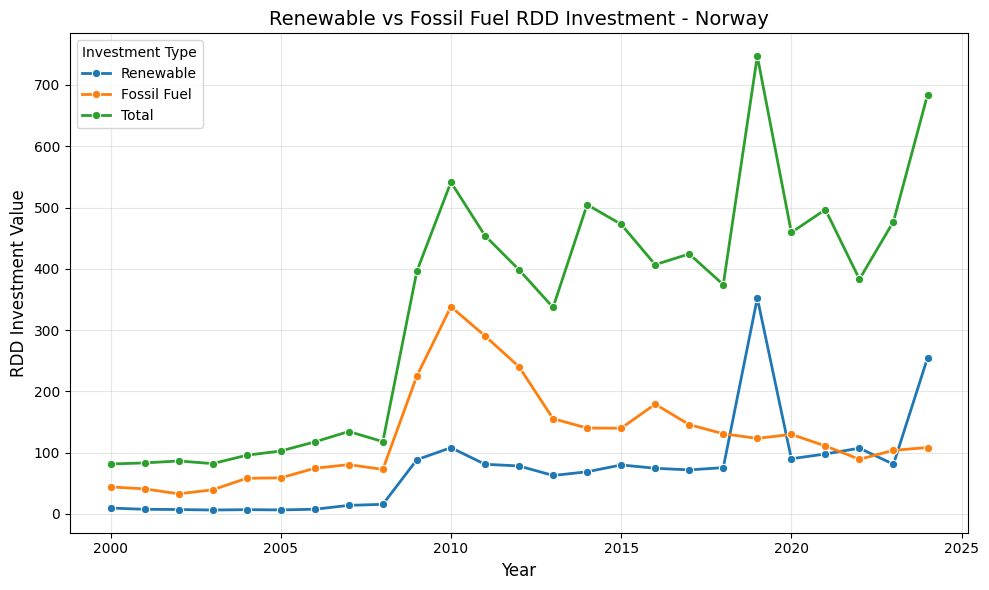

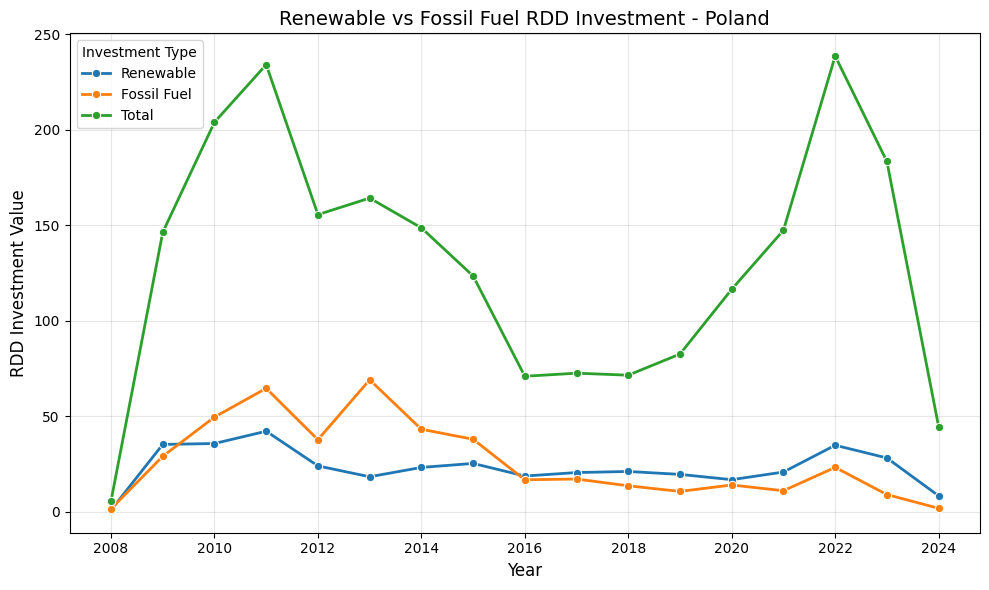

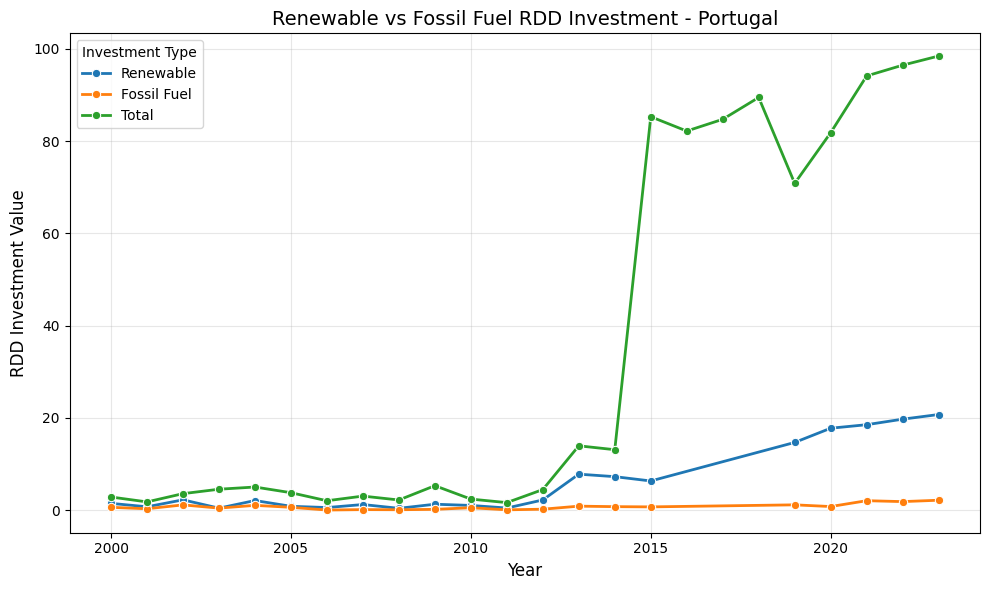

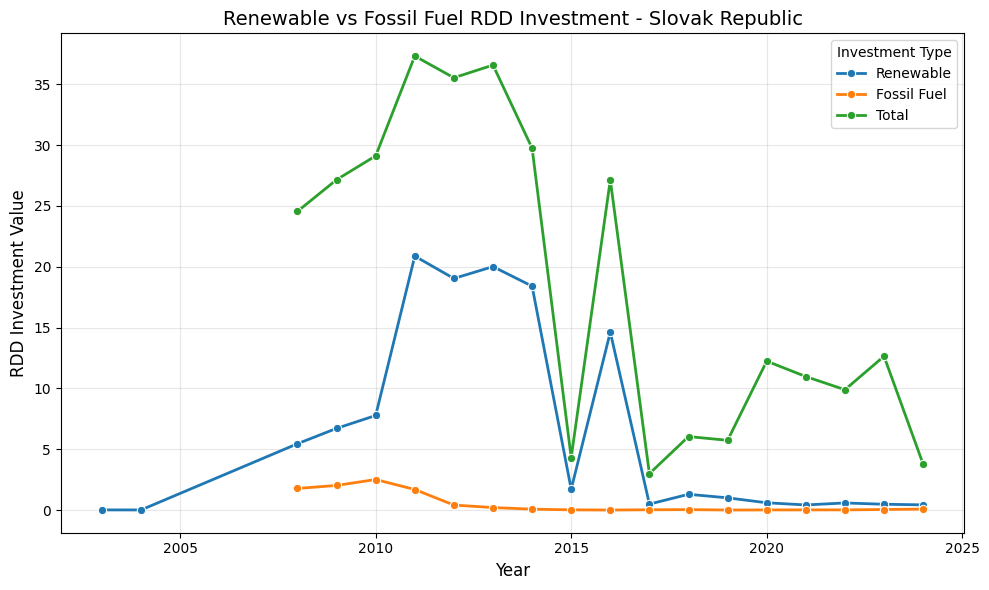

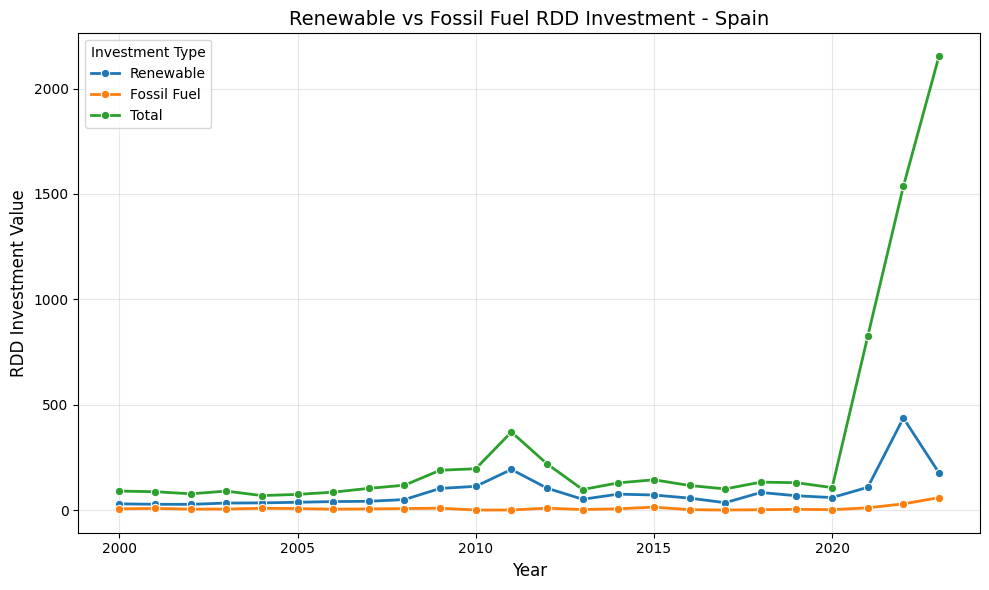

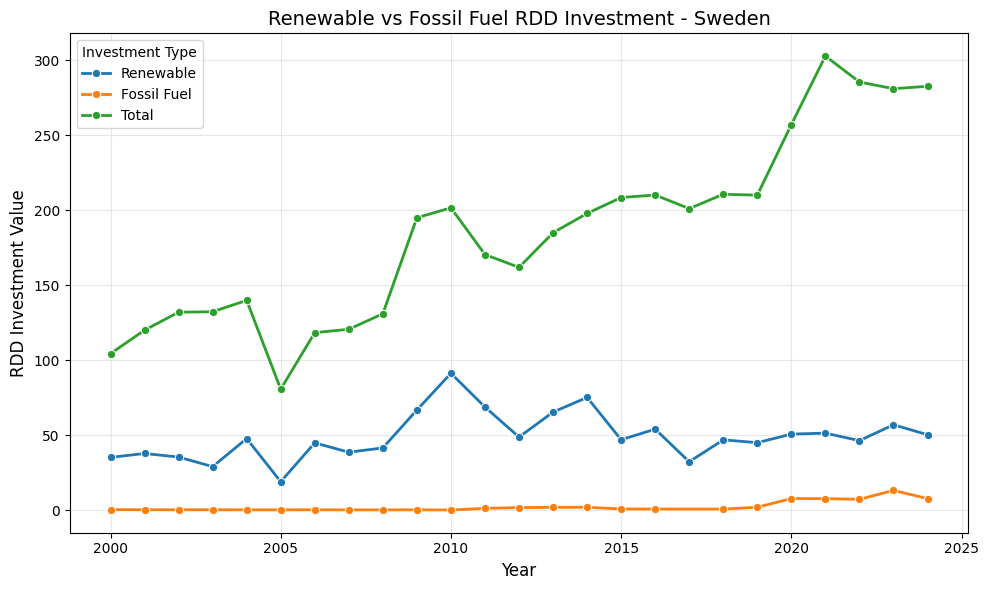

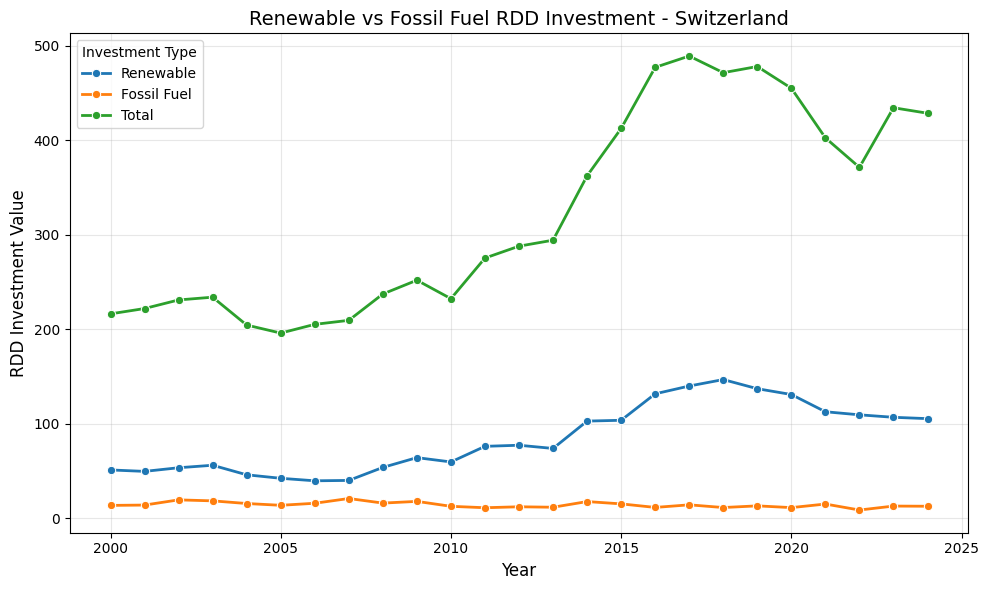

/tmp/ipykernel_282775/2193988868.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Investment Type', loc='best')


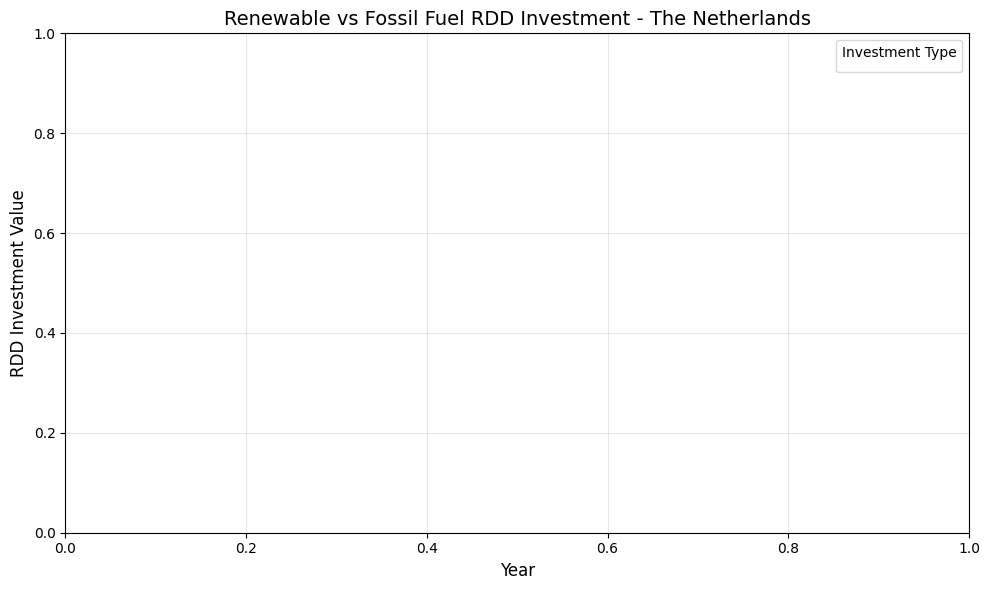

/tmp/ipykernel_282775/2193988868.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Investment Type', loc='best')


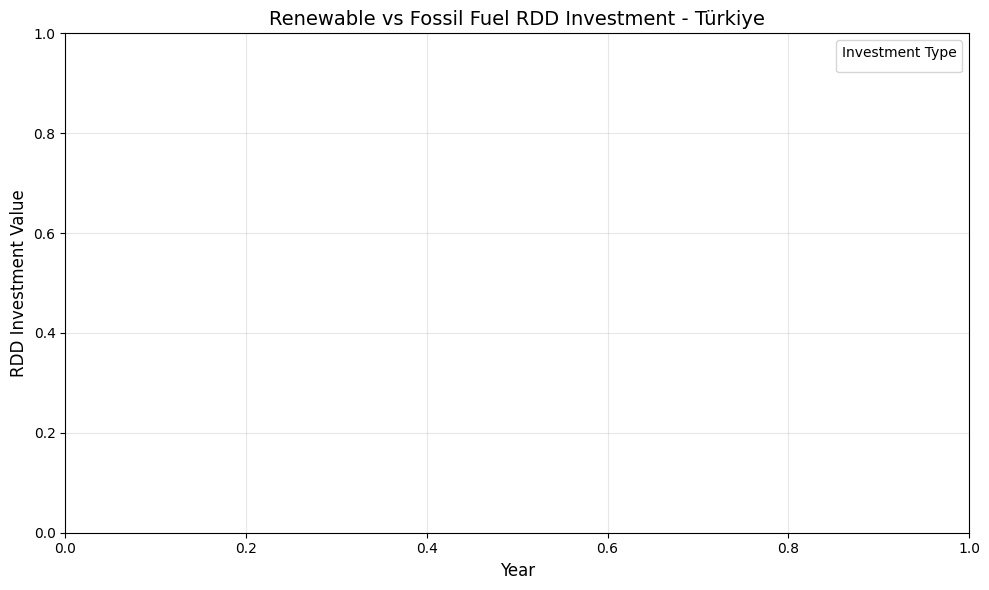

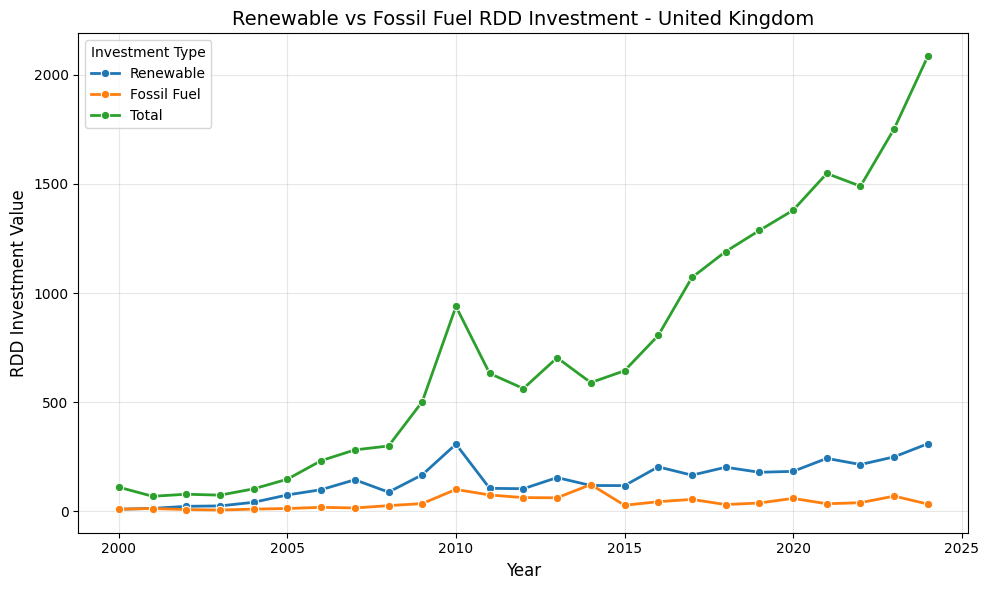

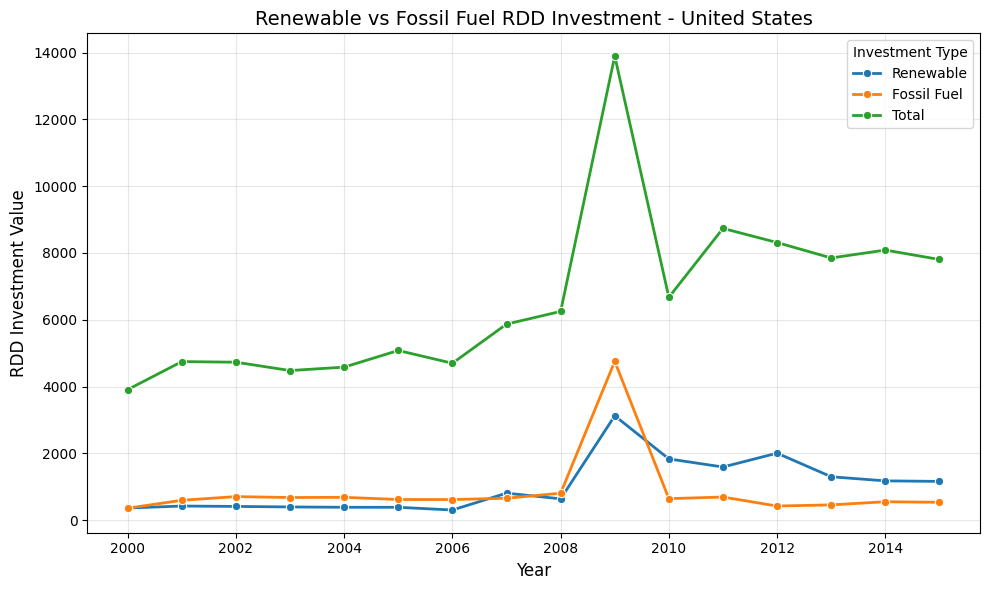

In [62]:
selected_renewable_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.RENEWABLE)
selected_fossilfuel_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.FOSSILFUEL)
selected_total_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.TOTAL)
selected_renewable_rdd['Investment_Type'] = 'Renewable'
selected_fossilfuel_rdd['Investment_Type'] = 'Fossil Fuel'
selected_total_rdd['Investment_Type'] = 'Total'
combined_rdd = pd.concat([selected_renewable_rdd, selected_fossilfuel_rdd, selected_total_rdd], ignore_index=True)

#Plot Renewable vs Fossilfuel RDD Investment Over Time by Country

for country in SELECTED_COUNTRIES:
    country_data = combined_rdd[combined_rdd['Country/Region'] == country]
    
    plt.figure(figsize=(10, 6))
    snus.lineplot(
        data=country_data,
        x='Year',
        y='Investment Amount (Million US$)',
        hue='Investment_Type',
        marker='o',
        linewidth=2
    )
    plt.title(f'Renewable vs Fossil Fuel RDD Investment - {country}', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('RDD Investment Value', fontsize=12)
    plt.legend(title='Investment Type', loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

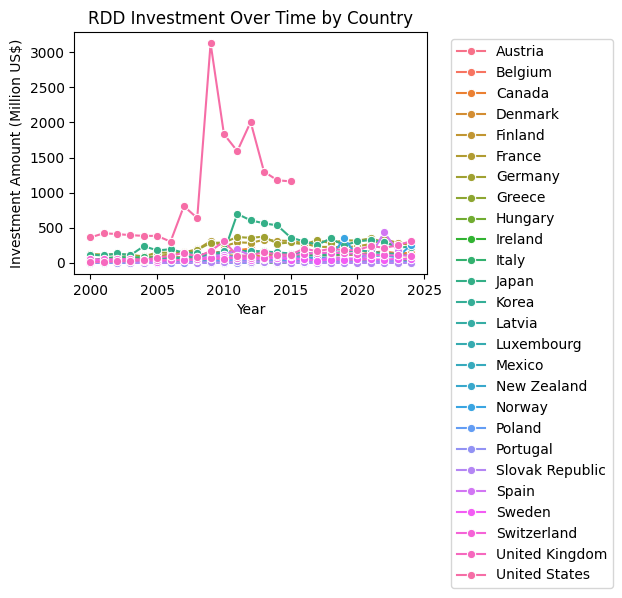

In [63]:
snus.lineplot(
    data=selected_renewable_rdd, 
    x='Year', 
    y='Investment Amount (Million US$)', 
    hue='Country/Region', 
    marker='o'
)
plt.title('RDD Investment Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [64]:
def get_generation_by_country(country_list, energy_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Electricity generation']
        country_data = country_data[country_data['Variable'] == energy_type]
        country_data = country_data[country_data['Unit'] == 'TWh']

        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def get_emissions_by_country(country_list, emission_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Power sector emissions']
        country_data = country_data[country_data['Variable'] == emission_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df


def get_relative_emission_to_year_by_country(country_list, start_year, emission_type):
    emission_data = get_emissions_by_country(country_list, emission_type)
    emission_data = emission_data[emission_data['Country/Region'].isin(country_list)].copy()

    # Sort for safety
    emission_data = emission_data.sort_values(['Country/Region', 'Year'])

    # Extract baseline values for each country
    start_year_data = emission_data[emission_data['Year'] == start_year][
        ['Country/Region', 'Value']
    ].rename(columns={'Value': 'StartValue'})

    # Merge baseline into dataset
    emission_data = emission_data.merge(start_year_data, on='Country/Region', how='left')

    # Calculate percent change (positive and negative)
    emission_data['Emission change (%)'] = (
        (emission_data['Value'] / emission_data['StartValue'] - 1) * 100
    )

    # Remove rows where start value does not exist
    emission_data = emission_data.dropna(subset=['Emission change (%)'])

    return emission_data

def get_relative_renewable_generation_to_year_by_country(country_list, start_year, generation_type):
    generation_data = get_generation_by_country(country_list, generation_type)
    generation_data = generation_data[generation_data['Country/Region'].isin(country_list)].copy()

    # Sort for safety
    generation_data = generation_data.sort_values(['Country/Region', 'Year'])

    # Extract baseline values for each country
    start_year_data = generation_data[generation_data['Year'] == start_year][
        ['Country/Region', 'Value']
    ].rename(columns={'Value': 'StartValue'})

    # Merge baseline into dataset
    generation_data = generation_data.merge(start_year_data, on='Country/Region', how='left')

    # Calculate percent change (positive and negative)
    generation_data['Renewable generation change (%)'] = (
        (generation_data['Value'] / generation_data['StartValue'] - 1) * 100
    )

    # Remove rows where start value does not exist
    generation_data = generation_data.dropna(subset=['Renewable generation change (%)'])
    generation_data = generation_data.drop_duplicates(subset=['Country/Region', 'Year'])

    return generation_data



In [65]:
def get_country_gdp_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'GDP (current US$)')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'GDP'})
    return grouped

def get_country_population_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'Population, total')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'Population'})
    return grouped

def get_combined_gdp(country_list):
    gdp_data = get_country_gdp_sum(country_list)
    gdp_data = gdp_data.groupby('Year')['GDP'].sum().reset_index()
    return gdp_data

def  calculate_investment_per_gdp(investment_df, gdp_df,
                                 inv_country_col='Country/Region',
                                 inv_year_col='Year',
                                 gdp_country_col='Country Name',   # optional
                                 gdp_year_col='Year',
                                 investment_col='Investment Amount (Million US$)',
                                 gdp_col='GDP'):
    inv = investment_df.copy()
    gdp = gdp_df.copy()

    # Harmonize dtypes
    inv[inv_year_col] = pd.to_numeric(inv[inv_year_col], errors='coerce').astype('Int64')
    gdp[gdp_year_col] = pd.to_numeric(gdp[gdp_year_col], errors='coerce').astype('Int64')

    inv[investment_col] = pd.to_numeric(inv[investment_col], errors='coerce')
    gdp[gdp_col]       = pd.to_numeric(gdp[gdp_col],       errors='coerce')

    # Clean strings
    if inv_country_col in inv.columns:
        inv[inv_country_col] = inv[inv_country_col].astype(str).str.strip()
    if gdp_country_col in gdp.columns:
        gdp[gdp_country_col] = gdp[gdp_country_col].astype(str).str.strip()

    # Decide merge keys
    has_gdp_country = gdp_country_col in gdp.columns
    if has_gdp_country:
        merge_left_on  = [inv_country_col, inv_year_col]
        merge_right_on = [gdp_country_col, gdp_year_col]
        validate_rule  = 'many_to_one'   # each (country, year) -> one GDP row
    else:
        merge_left_on  = [inv_year_col]
        merge_right_on = [gdp_year_col]
        validate_rule  = 'many_to_one'

    merged = pd.merge(
        inv, gdp,
        left_on=merge_left_on,
        right_on=merge_right_on,
        how='left',
        validate=validate_rule
    )

    # Avoid divide-by-zero
    denom = merged[gdp_col].replace(0, np.nan)
    merged['Investment_per_GDP'] = merged[investment_col] * np.power(10, 6) / denom

    # Pick tidy columns to return
    keep_cols = []
    if inv_country_col in merged.columns:
        keep_cols.append(inv_country_col)
    keep_cols += [inv_year_col, investment_col, gdp_col, 'Investment_per_GDP']

    return merged[keep_cols]

def calculate_relative_investment_per_gdp(country_list,comparison_country,type: RDD_TYPE):

    country_list_investment = get_rdd_investment(country_list, type)
    country_list_gdp = get_country_gdp_sum(country_list)
    country_list_investment_per_gdp = calculate_investment_per_gdp(country_list_investment, country_list_gdp)

    comparison_country_investment = get_rdd_investment([comparison_country], type)
    if(comparison_country == 'Total IEA'): 
        comparison_country_gdp = get_combined_gdp(IAE_COMBINED)
    else:
        comparison_country_gdp = get_country_gdp_sum([comparison_country])
    
    comparison_country_investment_per_gdp = calculate_investment_per_gdp(comparison_country_investment, comparison_country_gdp)

    merged = country_list_investment_per_gdp.merge(comparison_country_investment_per_gdp, on='Year', suffixes=('_country', '_comparison'))
    merged['Relative_Investment_per_GDP'] = ((merged['Investment_per_GDP_country'] / merged['Investment_per_GDP_comparison']) - 1)*100
    merged.drop(columns=['Investment Amount (Million US$)_country', 'GDP_country',
       'Investment_per_GDP_country', 'Country/Region_comparison',
       'Investment Amount (Million US$)_comparison', 'GDP_comparison',
       'Investment_per_GDP_comparison',], inplace=True)
    merged.rename(columns={'Country/Region_country': 'Country/Region'}, inplace=True)
    return merged

def get_year(df, year):
    return df[df['Year'] == year]
    

def show_relative_barplot(dataframe, year):
    df_sorted = dataframe.copy()
    
    min_val = df_sorted['Relative_Investment_per_GDP'].min()
    max_val = df_sorted['Relative_Investment_per_GDP'].max()
    
    colors = []
    for v in df_sorted['Relative_Investment_per_GDP']:
        if v < 0:
            norm = abs(v) / abs(min_val) if min_val != 0 else 0
            colors.append(plt.cm.Reds(norm * 0.4 + 0.4))
        elif v > 0:
            norm = v / max_val if max_val != 0 else 0
            colors.append(plt.cm.Greens(norm * 0.4 + 0.4))
        else:
            colors.append('lightgray')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(
        df_sorted['Country/Region'],
        df_sorted['Relative_Investment_per_GDP'],
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )
    
    ax.axhline(0, color='black', linewidth=1.5, zorder=0)
    ax.set_title(f'Relative RDD Investment per GDP in {year} by Country vs Total IEA', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Country/Region', fontsize=12)
    ax.set_ylabel('Relative Investment per GDP (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
def get_relative_investment(country_list, comparison_country, type: RDD_TYPE):
    iae_renewable_investment = get_rdd_investment([comparison_country], type)
    iae_gdp = get_combined_gdp(IAE_COMBINED)
    iae_investment_gdp_scaled = calculate_investment_per_gdp(iae_renewable_investment, iae_gdp)

    selected_countries_renewable_investment = get_rdd_investment(country_list, type)
    selected_countries_gdp = get_country_gdp_sum(country_list)
    selected_countries_investment_gdp_scaled = calculate_investment_per_gdp(selected_countries_renewable_investment, selected_countries_gdp)

    return calculate_relative_investment_per_gdp(country_list,comparison_country, type)

def get_renewable_to_fossile_rdd_ratio(country_list):
    fossile_fuel_rdd = get_rdd_investment(country_list, RDD_TYPE.FOSSILFUEL)
    renewable_rdd = get_rdd_investment(country_list, RDD_TYPE.RENEWABLE)

    relative_rdd_investments = pd.merge(
        fossile_fuel_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )

    relative_rdd_investments['Renewable Percentage'] = relative_rdd_investments['Investment Amount (Million US$)_Renewable'] / (relative_rdd_investments['Investment Amount (Million US$)_Renewable'] + relative_rdd_investments['Investment Amount (Million US$)_FossilFuel']) * 100
    relative_rdd_investments['Fossile Fuel Percentage'] = relative_rdd_investments['Investment Amount (Million US$)_FossilFuel'] / (relative_rdd_investments['Investment Amount (Million US$)_Renewable'] + relative_rdd_investments['Investment Amount (Million US$)_FossilFuel']) * 100
    return relative_rdd_investments

def get_renewable_to_fossile_rdd_ratio_last_n_years(country_list, duration_in_years):
    fossile_fuel_rdd = get_rdd_investment_sum_last_n_years(country_list, duration_in_years, RDD_TYPE.FOSSILFUEL)
    renewable_rdd = get_rdd_investment_sum_last_n_years(country_list, duration_in_years, RDD_TYPE.RENEWABLE)

    relative_rdd_investments = pd.merge(
        fossile_fuel_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )

    relative_rdd_investments['Renewable Percentage'] = relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] / (relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] + relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel']) * 100
    relative_rdd_investments['Fossile Fuel Percentage'] = relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel'] / (relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] + relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel']) * 100
    return relative_rdd_investments

def get_rdd_investment_cumsum_since_year(country_list, start_year, type: RDD_TYPE):
    df = get_rdd_investment(country_list, type).copy()
    # keep only years from start_year onwards
    df = df[df['Year'] >= start_year]
    if df.empty:
        return df
    df = df.sort_values(['Country/Region', 'Year'])
    df[f'Cumulative_since_{start_year}'] = (
        df.groupby('Country/Region')['Investment Amount (Million US$)']
          .cumsum()
    )
    return df

def get_renewable_to_fossile_rdd_ratio_since_year(country_list, start_year):
    fossil_rdd = get_rdd_investment_cumsum_since_year(
        country_list, start_year, RDD_TYPE.FOSSILFUEL
    )
    renewable_rdd = get_rdd_investment_cumsum_since_year(
        country_list, start_year, RDD_TYPE.RENEWABLE
    )
    rdd_combined = pd.merge(
        fossil_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )
    fossil_col = f'Cumulative_since_{start_year}_FossilFuel'
    renew_col = f'Cumulative_since_{start_year}_Renewable'
    total = rdd_combined[renew_col] + rdd_combined[fossil_col]
    rdd_combined = rdd_combined[total != 0].copy()
    total = total[total != 0]

    rdd_combined['Renewable Percentage'] = (rdd_combined[renew_col] / total) * 100
    rdd_combined['Fossile Fuel Percentage'] = (rdd_combined[fossil_col] / total) * 100

    return rdd_combined


In [66]:

relative_renewable_investments = get_relative_investment(IAE_MEMBERS, 'Total IEA', RDD_TYPE.RENEWABLE)
relative_fossilfuel_investments = get_relative_investment(IAE_MEMBERS, 'Total IEA', RDD_TYPE.FOSSILFUEL)
# snus.lineplot(
#     data=relative_renewable_investments,
#     x='Year',
#     y='Relative_Investment_per_GDP',
#     hue='Country/Region',
#     marker='o'
# )
# plt.title('Relative RDD Investment per GDP Over Time by Country vs Total IEA')
# plt.axhline(0, color='gray', linestyle='--')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# combined_investment_gdp = pd.concat([iae_investment_gdp_scaled, selected_countries_investment_gdp_scaled], ignore_index=True)
# snus.lineplot(
#     data=combined_investment_gdp, 
#     x='Year', 
#     y='Investment_per_GDP', 
#     hue='Country/Region', 
#     marker='o'
# )
# plt.title('RDD Investment per GDP Over Time by Country')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

relative_renewable_investments_2016 = get_year(relative_renewable_investments, 2016).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_renewable_investments_2020 = get_year(relative_renewable_investments, 2020).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_renewable_investments_2023 = get_year(relative_renewable_investments, 2023).sort_values(by='Relative_Investment_per_GDP', ascending=True)
# show_relative_barplot(relative_renewable_investments_2016, 2016)
# show_relative_barplot(relative_renewable_investments_2020, 2020)
# show_relative_barplot(relative_renewable_investments_2023, 2023)

relative_fossilfuel_investments_2016 = get_year(relative_fossilfuel_investments, 2016).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_fossilfuel_investments_2020 = get_year(relative_fossilfuel_investments, 2020).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_fossilfuel_investments_2023 = get_year(relative_fossilfuel_investments, 2023).sort_values(by='Relative_Investment_per_GDP', ascending=True)
# show_relative_barplot(relative_fossilfuel_investments_2016, 2016)
# show_relative_barplot(relative_fossilfuel_investments_2020, 2020)
# show_relative_barplot(relative_fossilfuel_investments_2023, 2023)



# relative_emission_data = get_relative_emission_to_year_by_country(RDD_IMPACT_COUNTRY_SELECTION, 2005, 'Renewables')

# relative_rdd_to_emission = pd.merge(
#     relative_rdd_investments,
#     relative_emission_data[['Country/Region', 'Year', 'Emission change (%)']],
#     on=['Country/Region', 'Year'],
#     how='inner'
# )
# #only very 4 years 
# relative_rdd_to_emission = relative_rdd_to_emission[
#     relative_rdd_to_emission['Year'] % 5 == 0
# ]

# show_bubbleplot(
#     relative_rdd_to_emission,
#     x = 'Year',
#     y ='Renewable Percentage',
#     size='Emission change (%)'
# )

# print(relative_rdd_to_emission.head())
# plt.figure(figsize=(10, 6))
# snus.lineplot(
#     data=relative_rdd_to_emission,
#     x='Year',
#     y='Emission change (%)',
#     hue='Country/Region',
#     marker='o'
# )

# plt.title('Renewable RDD Investment Percentage Over Time by Country')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# show_scatterplot(
#     data=relative_rdd_to_emission,
#     x='Year',
#     y='Renewable Percentage',
#     hue='Country/Region',
#     title='Relative RDD Investment per GDP in 2016: Fossil Fuel vs Renewable',
#     xlabel='Fossil Fuel Relative Investment per GDP (%)',
#     ylabel='Renewable Relative Investment per GDP (%)'
# )







## Renewable Energy RD&D Detailed View
In what kind of renewable energies do countries invest. How does this change over time ? 

In [67]:
def get_rdd_renewable_detailed(country_list):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = rdd_renewable_detail_content[rdd_renewable_detail_content['Country/Region']==country]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def show_renewable_detailed_investment_stacked_column_chart(country_list):
    for country in country_list:
        country_data = get_rdd_renewable_detailed([country])
        renewable_data = country_data[country_data['Type'] == 'RENEWABLE']
        country_data = country_data[country_data['Type'] != 'RENEWABLE']
        merged = pd.merge(
            country_data,
            renewable_data[['Country/Region', 'Year', 'Investment Amount (Million US$)']],
            on=['Country/Region', 'Year'],
            suffixes=('', '_Total')
        )
        
        merged['Investment Percent'] = merged['Investment Amount (Million US$)'] / merged['Investment Amount (Million US$)_Total'] * 100
        
        pivot_df = merged.pivot_table(
            index='Year',
            columns='Type',
            values='Investment Percent',
            aggfunc='sum',
            fill_value=0
        )
        
        # Sort columns by total sum (descending) so largest are at bottom of stack
        column_sums = pivot_df.sum(axis=0).sort_values(ascending=False)
        pivot_df = pivot_df[column_sums.index]
        
        pivot_df.plot(
            kind='bar',
            stacked=True,
            figsize=(12, 6),
            colormap='tab20'
        )
        plt.title(f'Renewable RDD Investment Breakdown by Technology - {country}', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Investment Percentage (%)', fontsize=12)
        plt.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        pivot_df = country_data.pivot_table(
            index='Year',
            columns='Type',
            values='Investment Amount (Million US$)',
            aggfunc='sum',
            fill_value=0
        )
        
        # Sort columns by total sum (descending) so largest are at bottom of stack
        column_sums = pivot_df.sum(axis=0).sort_values(ascending=False)
        pivot_df = pivot_df[column_sums.index]
        
        pivot_df.plot(
            kind='bar',
            stacked=True,
            figsize=(12, 6),
            colormap='tab20'
        )
        plt.title(f'Renewable RDD Investment Breakdown by Technology - {country}', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Investment (Million US$)', fontsize=12)
        plt.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    



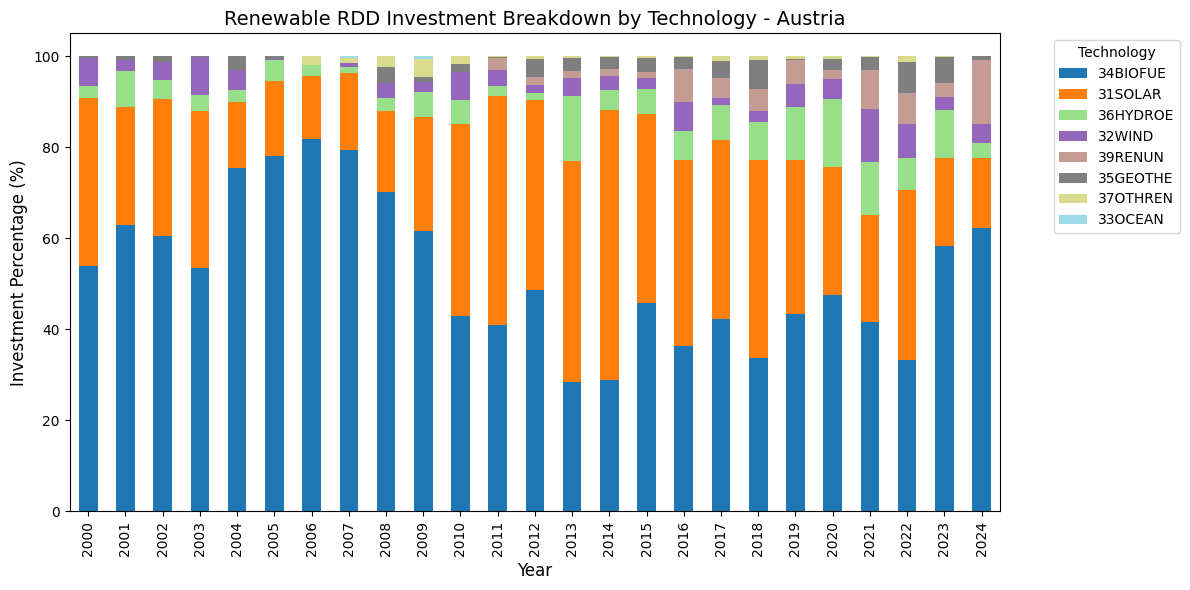

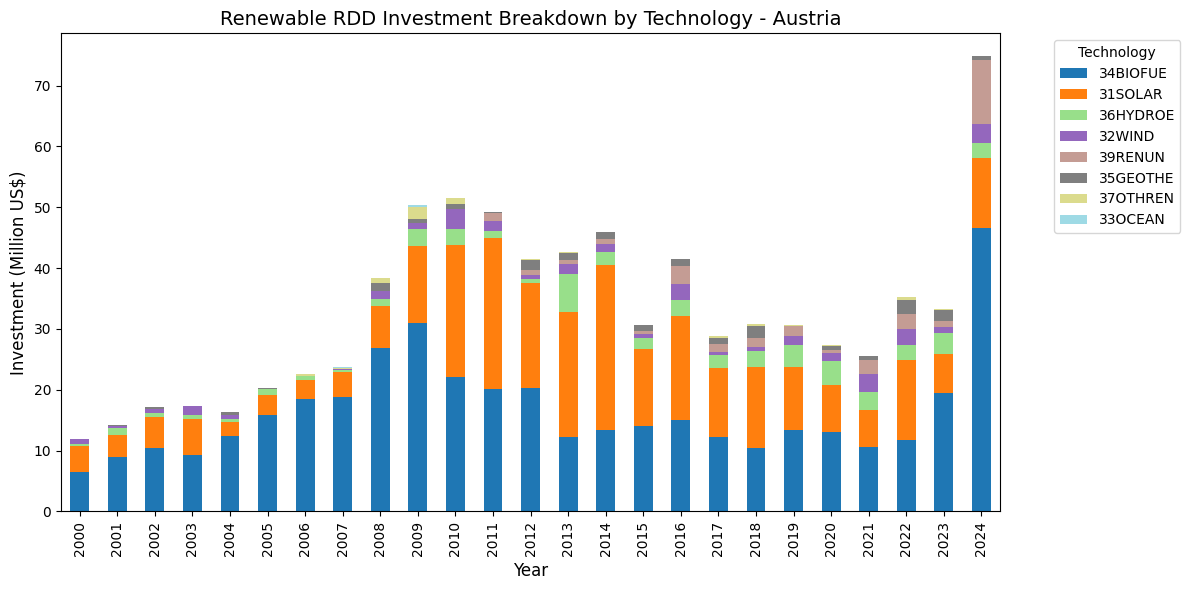

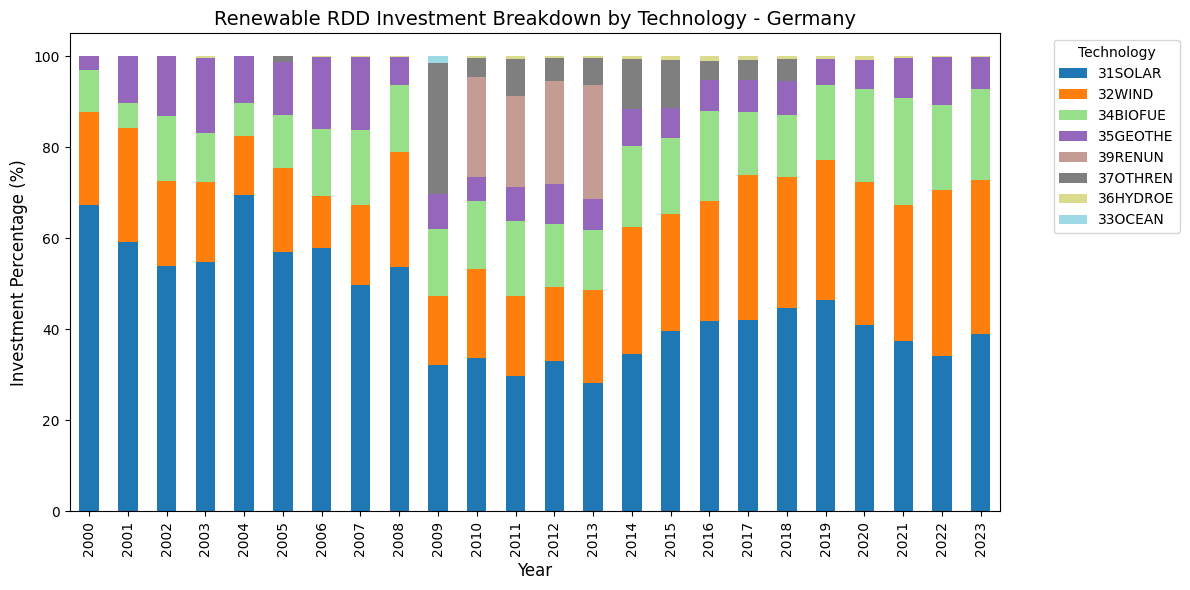

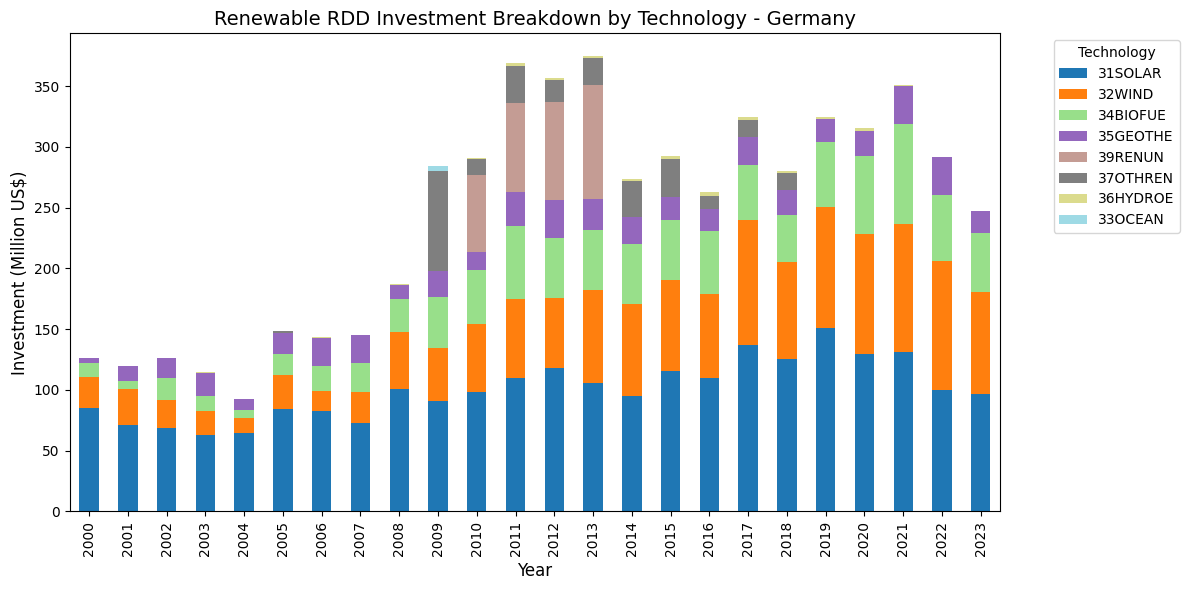

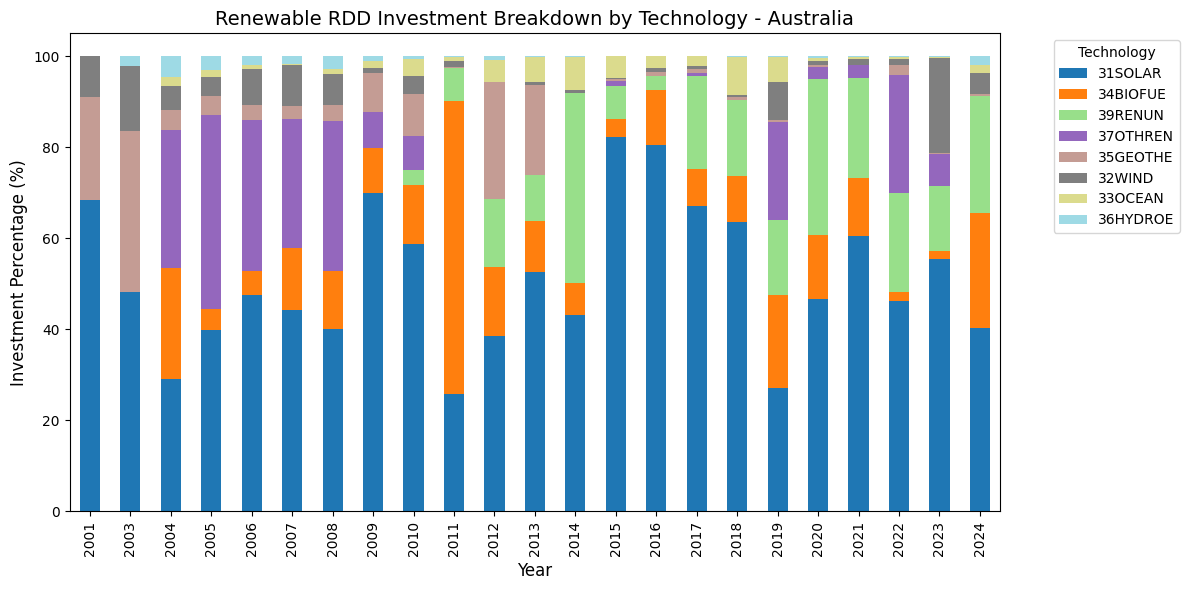

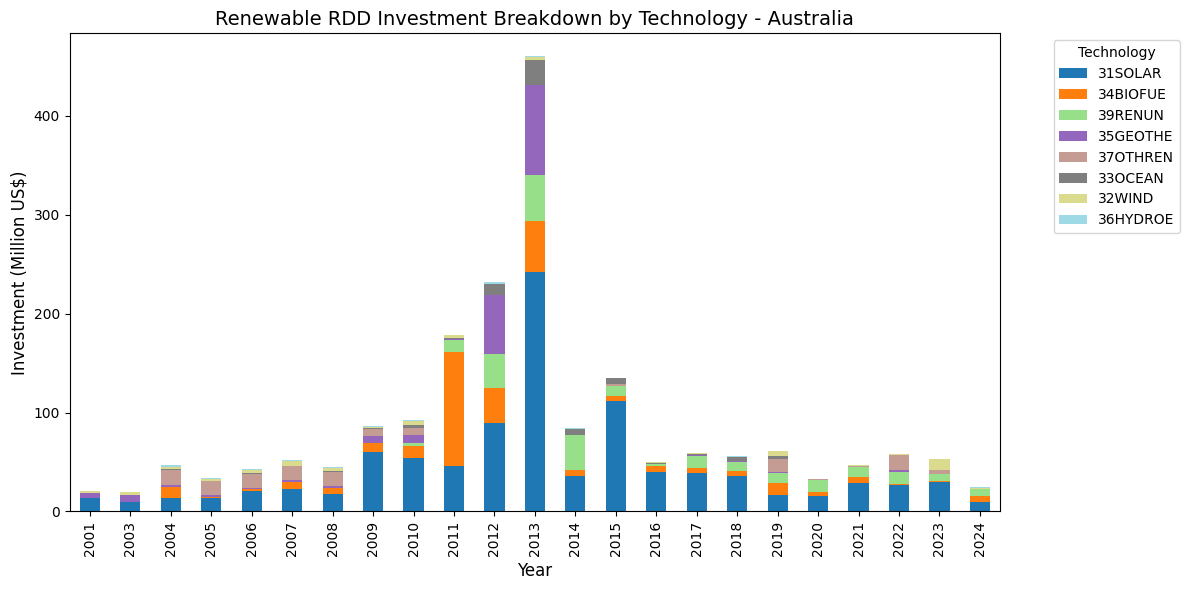

In [68]:
show_renewable_detailed_investment_stacked_column_chart(['Austria','Germany','Australia'])

## RD&D Investment relations to energy generation and CO2 emissions

Does the type of rdd investment influence type of energy generation and co2 emission ? 

I assume that the affects of rdd projects in this field take 10 years to affect generation and co2 emissions

Are countries who invest more in rdd and have a higher renewable energy percentage less subceptible to flucuating electrictiy prices.


In [69]:
def get_generation_by_country(country_list, energy_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Electricity generation']
        country_data = country_data[country_data['Variable'] == energy_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def get_emissions_by_country(country_list, emission_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Power sector emissions']
        country_data = country_data[country_data['Variable'] == emission_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df



In [70]:
import matplotlib.pyplot as plt
import numpy as np

def show_scatterplot_best_worst(data, x, y,
                                title=None, xlabel=None, ylabel=None,
                                fit_line=False):

    plt.figure(figsize=(10, 6))

    # Extract numeric x/y
    xs = data[x].astype(float)
    ys = data[y].astype(float)

    # Identify min and max
    min_idx = xs.idxmin()
    max_idx = xs.idxmax()

    # Color scheme
    best_color  = "#0072B2"  # blue
    worst_color = "#D55E00"  # orange
    other_color = "#999999"  # gray

    # Plot ALL other points first (gray)
    others = data.drop([min_idx, max_idx])
    plt.scatter(
        others[x], others[y],
        color=other_color, s=60, alpha=0.6, label="Other"
    )

    # Plot WORST
    plt.scatter(
        data.loc[min_idx, x],
        data.loc[min_idx, y],
        color=worst_color, s=180, edgecolor="black", linewidth=1.5,
        label=f"Worst ({data.loc[min_idx, x]:.2f})"
    )

    # Plot BEST
    plt.scatter(
        data.loc[max_idx, x],
        data.loc[max_idx, y],
        color=best_color, s=180, edgecolor="black", linewidth=1.5,
        label=f"Best ({data.loc[max_idx, x]:.2f})"
    )

    # Regression line
    if fit_line:
        m, b = np.polyfit(xs, ys, 1)
        plt.plot(xs, m*xs + b, color='black', linewidth=2, alpha=0.7)

    # Labels
    plt.title(title if title else "Scatter Plot", fontsize=14)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Index(['Country/Region', 'Type_FossilFuel', 'Unit_FossilFuel', 'Year',
       'Investment Amount (Million US$)_FossilFuel',
       'Unit Multiplier_FossilFuel', 'Cumulative_since_2000_FossilFuel',
       'Type_Renewable', 'Unit_Renewable',
       'Investment Amount (Million US$)_Renewable',
       'Unit Multiplier_Renewable', 'Cumulative_since_2000_Renewable',
       'Renewable Percentage', 'Fossile Fuel Percentage',
       'Emission change (%)'],
      dtype='object')


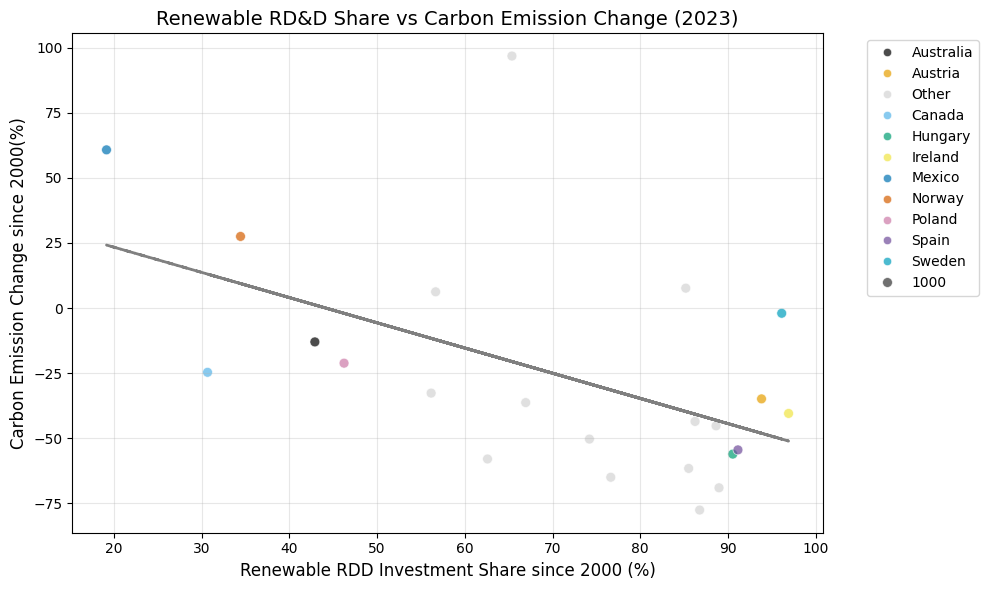

In [71]:
rdd_ratio_since_2005 = get_renewable_to_fossile_rdd_ratio_since_year(IAE_MEMBERS, 2000)
relative_emission_data = get_relative_emission_to_year_by_country(IAE_MEMBERS, 2000, 'Total emissions')
relative_rdd_to_emission = pd.merge(
    rdd_ratio_since_2005,
    relative_emission_data[['Country/Region', 'Year', 'Emission change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)
print(relative_rdd_to_emission.columns)
#only very 4 years 
# relative_rdd_to_emission = relative_rdd_to_emission[
#     relative_rdd_to_emission['Year'] % 5 == 0
# ]

relative_rdd_to_emission_2023 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2023]


show_scatterplot(
    data=relative_rdd_to_emission_2023,
    x='Renewable Percentage',
    y='Emission change (%)',
    hue='Country/Region',
    title='Renewable RD&D Share vs Carbon Emission Change (2023)',
    xlabel='Renewable RDD Investment Share since 2000 (%)',
    ylabel='Carbon Emission Change since 2000(%)',
    size=1000,
    fit_line=True
)

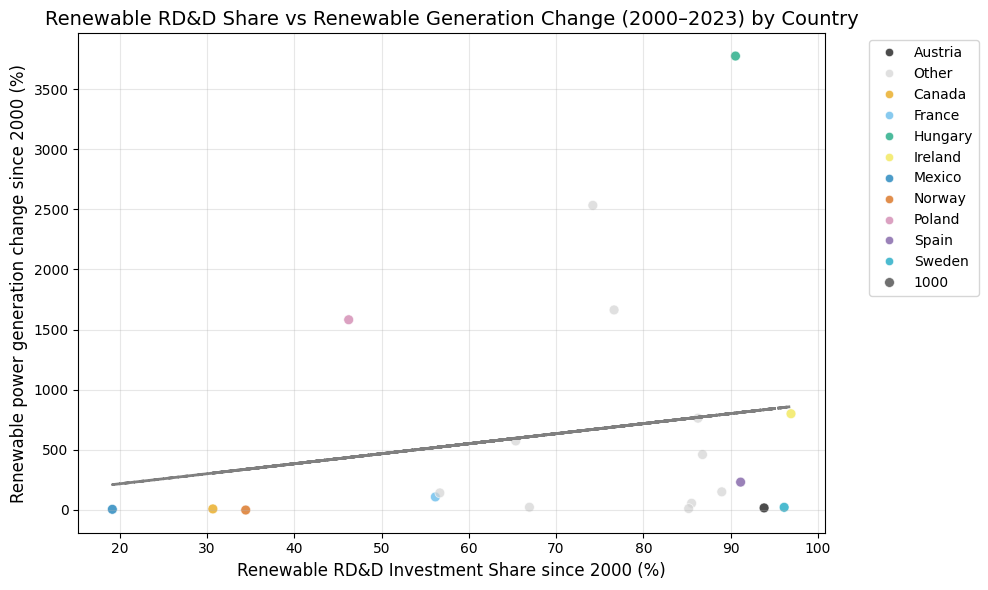

In [72]:
rdd_ratio_since_2005 = get_renewable_to_fossile_rdd_ratio_since_year(SELECTED_COUNTRIES, 2000)
relative_emission_data = get_relative_emission_to_year_by_country(SELECTED_COUNTRIES, 2000, 'Total emissions')
relative_renewable_generation = get_relative_renewable_generation_to_year_by_country(SELECTED_COUNTRIES, 2000, 'Renewables')

relative_rdd_to_emission = pd.merge(
    rdd_ratio_since_2005,
    relative_renewable_generation[['Country/Region', 'Year', 'Renewable generation change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)
#only very 4 years 
# relative_rdd_to_emission = relative_rdd_to_emission[
#     relative_rdd_to_emission['Year'] % 5 == 0
# ]


relative_rdd_to_emission_2023 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2023]

show_scatterplot(
    data=relative_rdd_to_emission_2023,
    x='Renewable Percentage',
    y='Renewable generation change (%)',
    hue='Country/Region',
    title='Renewable RD&D Share vs Renewable Generation Change (2000–2023) by Country',
    xlabel='Renewable RD&D Investment Share since 2000 (%)',
    ylabel='Renewable power generation change since 2000 (%)',
    size=1000,
    fit_line=True
)

In [73]:
def append_ts_frame(ts_frames, df, value_col, type_label, region,
                    year_col='Year', rename_to='Investment_per_GDP',
                    coerce_numeric=False):
    if value_col not in df.columns:
        return None

    tmp = df[[year_col, value_col]].copy()
    if coerce_numeric:
        tmp[value_col] = pd.to_numeric(tmp[value_col], errors='coerce')
    tmp = tmp.dropna().reset_index(drop=True)
    if tmp.empty:
        return None

    tmp = tmp.rename(columns={value_col: rename_to})
    tmp['Type'] = type_label
    tmp['Region'] = region

    ts_frames.append(tmp)
    return tmp

def build_aggregate_ts(renew_df, fossil_df, gdp_df,
                       invest_col="Investment Amount (Million US$)",
                       gdp_col="GDP",
                       prefix="iae"):
    renew_ts = (
        renew_df
        .groupby("Year")[invest_col]
        .sum()
        .reset_index(name=f"{prefix}_renew_musd")
    )
    fossil_ts = (
        fossil_df
        .groupby("Year")[invest_col]
        .sum()
        .reset_index(name=f"{prefix}_fossil_musd")
    )
    gdp_ts = (
        gdp_df
        .groupby("Year")[gdp_col]
        .sum()
        .reset_index(name=f"{prefix}_gdp")
    )

    out = (
        renew_ts
        .merge(fossil_ts, on="Year", how="inner")
        .merge(gdp_ts, on="Year", how="inner")
    )

    # compute per-GDP in absolute USD/GDP (convert million USD -> USD)
    out[f"{prefix}_renew_per_gdp"]  = out[f"{prefix}_renew_musd"]  * 1e6 / out[f"{prefix}_gdp"]
    out[f"{prefix}_fossil_per_gdp"] = out[f"{prefix}_fossil_musd"] * 1e6 / out[f"{prefix}_gdp"]

    out["Year"] = out["Year"].astype(int)
    return out


def build_country_ts(renew_df, fossil_df, gdp_df, *,
                     calculate_investment_per_gdp_fn,
                     renew_col_name="at_renew_per_gdp",
                     fossil_col_name="at_fossil_per_gdp"):
    renew_ts = calculate_investment_per_gdp_fn(renew_df, gdp_df).rename(
        columns={"Investment_per_GDP": renew_col_name}
    )
    fossil_ts = calculate_investment_per_gdp_fn(fossil_df, gdp_df).rename(
        columns={"Investment_per_GDP": fossil_col_name}
    )

    renew_ts["Year"] = renew_ts["Year"].astype(int)
    fossil_ts["Year"] = fossil_ts["Year"].astype(int)

    merged = renew_ts[["Year", renew_col_name]].merge(
        fossil_ts[["Year", fossil_col_name]], on="Year", how="outer"
    )
    return merged

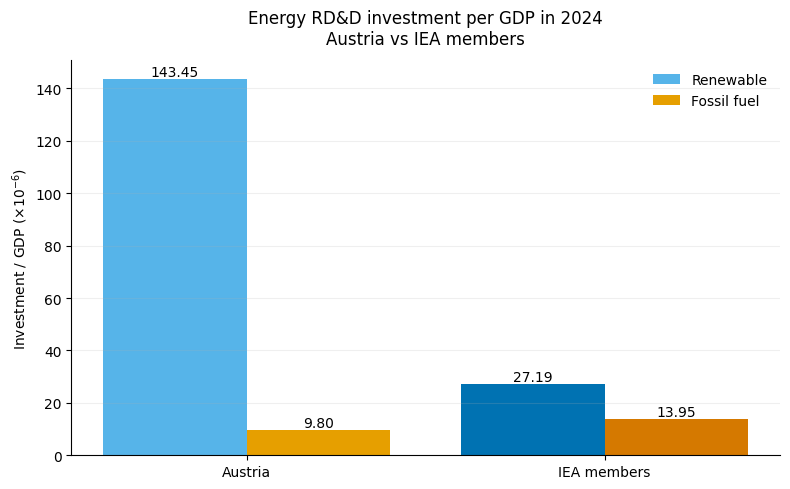

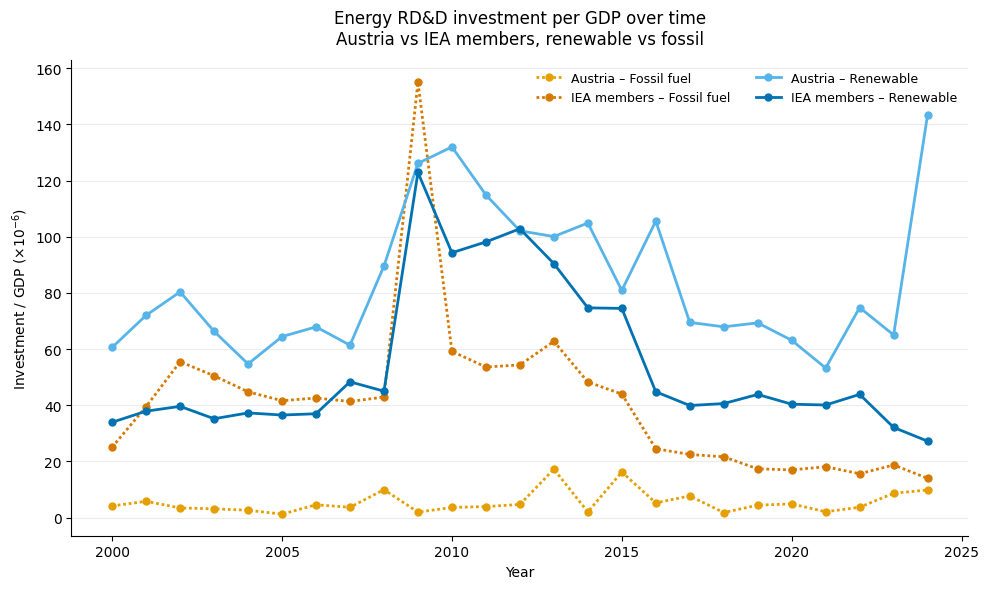

In [74]:

FOCUS_COUNTRY = "Austria"
GROUP_LABEL = "IEA members"  # label for the aggregate group in plots

latest_year = int(rdd_content["Year"].max())
previous_year = latest_year - 1

at_renewable   = get_rdd_investment([FOCUS_COUNTRY], RDD_TYPE.RENEWABLE)
at_fossil      = get_rdd_investment([FOCUS_COUNTRY], RDD_TYPE.FOSSILFUEL)
iae_renewable = get_rdd_investment(IAE_MEMBERS, RDD_TYPE.RENEWABLE)
iae_fossil    = get_rdd_investment(IAE_MEMBERS, RDD_TYPE.FOSSILFUEL)
at_gdp    = get_country_gdp_sum([FOCUS_COUNTRY])
iae_gdp = get_country_gdp_sum(IAE_MEMBERS)

for df in [at_renewable, at_fossil, iae_renewable, iae_fossil, at_gdp, iae_gdp]:
    df["Year"] = df["Year"].astype(int)

at_renewable_latest = at_renewable[at_renewable["Year"] == latest_year]
at_renewable_prev   = at_renewable[at_renewable["Year"] == previous_year]

at_fossil_latest = at_fossil[at_fossil["Year"] == latest_year]
at_fossil_prev   = at_fossil[at_fossil["Year"] == previous_year]

at_invest_renew_latest = at_renewable_latest["Investment Amount (Million US$)"].sum()
at_invest_fossil_latest = at_fossil_latest["Investment Amount (Million US$)"].sum()

at_gdp_latest = at_gdp[at_gdp["Year"] == latest_year]

at_per_gdp_renew = calculate_investment_per_gdp(
    at_renewable_latest,
    at_gdp_latest
)
at_per_gdp_fossil = calculate_investment_per_gdp(
    at_fossil_latest,
    at_gdp_latest
)

at_invest_per_gdp_renew  = float(at_per_gdp_renew["Investment_per_GDP"].iloc[0])
at_invest_per_gdp_fossil = float(at_per_gdp_fossil["Investment_per_GDP"].iloc[0])

iae_renewable_latest = iae_renewable[iae_renewable["Year"] == latest_year]
iae_fossil_latest    = iae_fossil[iae_fossil["Year"] == latest_year]
iae_gdp_latest       = iae_gdp[iae_gdp["Year"] == latest_year]

iae_total_gdp_latest = iae_gdp_latest["GDP"].sum()

iae_total_renew_latest = iae_renewable_latest["Investment Amount (Million US$)"].sum() * 1e6
iae_total_fossil_latest = iae_fossil_latest["Investment Amount (Million US$)"].sum() * 1e6

iae_invest_per_gdp_renew  = iae_total_renew_latest  / iae_total_gdp_latest
iae_invest_per_gdp_fossil = iae_total_fossil_latest / iae_total_gdp_latest

iae_ts = build_aggregate_ts(
    iae_renewable, iae_fossil, iae_gdp,
    invest_col="Investment Amount (Million US$)",
    gdp_col="GDP",
    prefix="iae"
)

at_ts = build_country_ts(
    at_renewable, at_fossil, at_gdp,
    calculate_investment_per_gdp_fn=calculate_investment_per_gdp,
    renew_col_name="at_renew_per_gdp",
    fossil_col_name="at_fossil_per_gdp"
)

ts_frames = []

append_ts_frame(ts_frames, at_ts,  'at_renew_per_gdp',  'Renewable',   FOCUS_COUNTRY)
append_ts_frame(ts_frames, at_ts,  'at_fossil_per_gdp', 'Fossil fuel', FOCUS_COUNTRY)
append_ts_frame(ts_frames, iae_ts, 'iae_renew_per_gdp', 'Renewable',   GROUP_LABEL)
append_ts_frame(ts_frames, iae_ts, 'iae_fossil_per_gdp','Fossil fuel', GROUP_LABEL)

ts_long = pd.concat(ts_frames, ignore_index=True)
ts_long = ts_long.sort_values("Year")
SCALE = 1e6
SCALE_LABEL = r"×10$^{-6}$"

combo_palette = {
    f"{FOCUS_COUNTRY} – Renewable":    "#56B4E9",  # light sky blue
    f"{FOCUS_COUNTRY} – Fossil fuel":  "#E69F00",  # light orange
    f"{GROUP_LABEL} – Renewable":      "#0072B2",  # dark blue
    f"{GROUP_LABEL} – Fossil fuel":    "#D57900",  # dark orange
}

plt.figure(figsize=(8, 5))

regions = [FOCUS_COUNTRY, GROUP_LABEL]
types   = ["Renewable", "Fossil fuel"]
bar_width = 0.4  

x = np.arange(len(regions))

vals = {
    FOCUS_COUNTRY: {
        "Renewable":   at_invest_per_gdp_renew  * SCALE,
        "Fossil fuel": at_invest_per_gdp_fossil * SCALE,
    },
    GROUP_LABEL: {
        "Renewable":   iae_invest_per_gdp_renew  * SCALE,
        "Fossil fuel": iae_invest_per_gdp_fossil * SCALE,
    }
}
renew_x = x - bar_width/2
foss_x  = x + bar_width/2
plt.bar(
    renew_x,
    [vals[r]["Renewable"] for r in regions],
    width=bar_width,
    color=[combo_palette[f"{r} – Renewable"] for r in regions],
    label="Renewable"
)
plt.bar(
    foss_x,
    [vals[r]["Fossil fuel"] for r in regions],
    width=bar_width,
    color=[combo_palette[f"{r} – Fossil fuel"] for r in regions],
    label="Fossil fuel"
)
for xx, region in zip(renew_x, regions):
    v = vals[region]["Renewable"]
    plt.text(xx, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

for xx, region in zip(foss_x, regions):
    v = vals[region]["Fossil fuel"]
    plt.text(xx, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
plt.xticks(x, regions)
plt.ylabel(f"Investment / GDP ({SCALE_LABEL})")
plt.title(
    f"Energy RD&D investment per GDP in {latest_year}\n"
    f"{FOCUS_COUNTRY} vs {GROUP_LABEL}",
    pad=12
)

plt.grid(axis="y", alpha=0.2)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

#Linechart
plt.figure(figsize=(10, 6))

ts_plot = ts_long.copy()
ts_plot["Investment_per_GDP_scaled"] = ts_plot["Investment_per_GDP"] * SCALE

# Line styles by type: solid = renewable, dotted = fossil
line_styles = {
    "Renewable": "solid",
    "Fossil fuel": (0, (1, 1)),  # dotted
}

for (typ, reg), subset in ts_plot.groupby(["Type", "Region"]):
    plt.plot(
        subset["Year"],
        subset["Investment_per_GDP_scaled"],
        label=f"{reg} – {typ}",
        color=combo_palette[f"{reg} – {typ}"],
        linestyle=line_styles[typ],
        marker="o",
        markersize=5,
        linewidth=2
    )

plt.title(
    "Energy RD&D investment per GDP over time\n"
    f"{FOCUS_COUNTRY} vs {GROUP_LABEL}, renewable vs fossil",
    pad=12
)
plt.ylabel(f"Investment / GDP ({SCALE_LABEL})")
plt.xlabel("Year")
plt.grid(True, axis="y", alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(
    title="",
    frameon=False,
    ncol=2,
    fontsize=9
)

plt.tight_layout()
plt.show()


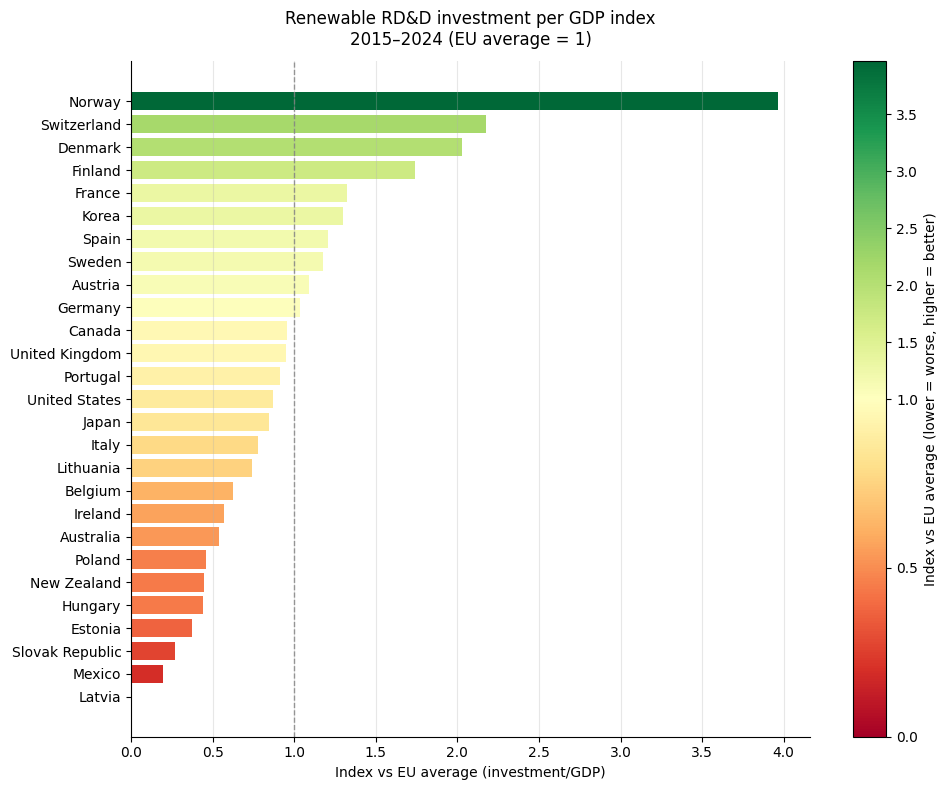

In [75]:
for dataframe in [iae_renewable, iae_gdp]:
    dataframe["Year"] = dataframe["Year"].astype(int)
latest_year = int(iae_renewable["Year"].max())
earliest_year = int(iae_renewable["Year"].min())
window_years = 10  # ten-year window
start_window_year = max(earliest_year, latest_year - window_years + 1)
renewable_investment_10y = iae_renewable[
    (iae_renewable["Year"] >= start_window_year) &
    (iae_renewable["Year"] <= latest_year)
].copy()
gdp_in_window = iae_gdp[
    (iae_gdp["Year"] >= start_window_year) &
    (iae_gdp["Year"] <= latest_year)
].copy()
aggregated_investments = calculate_investment_per_gdp(
    renewable_investment_10y,
    gdp_in_window
)
investments_in_window = (
    aggregated_investments
    .groupby("Country/Region")
    .agg(
        total_investment_million_usd=("Investment Amount (Million US$)", "sum"),
        total_gdp=("GDP", "sum")
    )
    .reset_index()
)
investments_in_window["investment_per_gdp_in_window"] = (
    investments_in_window["total_investment_million_usd"] * 1e6 / investments_in_window["total_gdp"]
)
eu_average_investment_per_gdp_in_window = investments_in_window["investment_per_gdp_in_window"].mean()
investments_in_window["index_vs_eu_average"] = (
    investments_in_window["investment_per_gdp_in_window"] / eu_average_investment_per_gdp_in_window
)
investments_in_window_sorted = investments_in_window.sort_values("index_vs_eu_average")


# Plot horizontal bar chart
plt.figure(figsize=(10, 8))

colour_map = plt.colormaps.get_cmap("RdYlGn")
normalisation = mcolors.TwoSlopeNorm(
    vmin=investments_in_window_sorted["index_vs_eu_average"].min(),
    vcenter=1.0,
    vmax=investments_in_window_sorted["index_vs_eu_average"].max()
)
bar_colours = [
    colour_map(normalisation(value))
    for value in investments_in_window_sorted["index_vs_eu_average"]
]
axis = plt.gca()
axis.barh(
    investments_in_window_sorted["Country/Region"],
    investments_in_window_sorted["index_vs_eu_average"],
    color=bar_colours
)

axis.axvline(1.0, linestyle="--", linewidth=1, alpha=0.8, color="grey")  # EU average

axis.set_title(
    f"Renewable RD&D investment per GDP index\n"
    f"{start_window_year}–{latest_year} (EU average = 1)",
    pad=12
)
axis.set_xlabel("Index vs EU average (investment/GDP)")
axis.set_ylabel("")

axis.grid(axis="x", alpha=0.3)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

scalar_mappable = cm.ScalarMappable(cmap=colour_map, norm=normalisation)
scalar_mappable.set_array([])
colourbar = plt.colorbar(scalar_mappable, ax=axis)
colourbar.set_label("Index vs EU average (lower = worse, higher = better)")

plt.tight_layout()
plt.show()


## Develop Interactive dashboard

In [76]:
import unicodedata
import warnings

def make_country_key(s: pd.Series) -> pd.Series:
    # make sure it's string, strip whitespace, normalize accents consistently
    s = s.astype(str).str.strip()

    # Unicode normalize so e.g. "Côte d’Ivoire" variants become consistent
    s = s.map(lambda x: unicodedata.normalize("NFKC", x))

    # optional: collapse repeated whitespace
    s = s.str.replace(r"\s+", " ", regex=True)

    return s

def add_country_key(df: pd.DataFrame, country_col="Country/Region") -> pd.DataFrame:
    df = df.copy()
    df["country_key"] = make_country_key(df[country_col])
    return df

def warn_if_country_keys_differ(
    df_a,
    df_b,
    key="country_key",
    name_a="df_a",
    name_b="df_b",
    sample_size=10,
):
    """
    Compare country key sets between two DataFrames and warn if they differ.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        DataFrames to compare
    key : str
        Column name containing the country key
    name_a, name_b : str
        Human-readable names for warning messages
    sample_size : int
        Number of example keys to show in warnings
    """
    if key not in df_a.columns:
        raise KeyError(f"{key} not found in {name_a}")
    if key not in df_b.columns:
        raise KeyError(f"{key} not found in {name_b}")

    set_a = set(df_a[key].dropna().astype(str))
    set_b = set(df_b[key].dropna().astype(str))

    if set_a == set_b:
        return  # all good, silent success

    only_a = sorted(set_a - set_b)
    only_b = sorted(set_b - set_a)

    msg = [
        "Country key mismatch detected.",
        f"{name_a}: {len(set_a)} countries",
        f"{name_b}: {len(set_b)} countries",
    ]

    if only_a:
        msg.append(
            f"Only in {name_a} (sample): {only_a[:sample_size]}"
        )
    if only_b:
        msg.append(
            f"Only in {name_b} (sample): {only_b[:sample_size]}"
        )

    warnings.warn("\n".join(msg), UserWarning)


In [77]:
import holoviews as hv
import hvplot.pandas # noqa: F401 (registers hvplot on pandas objects)
KEY = "country_key"

rdd_ratio_since_2000 = get_renewable_to_fossile_rdd_ratio_since_year(IAE_MEMBERS, 2000)
relative_emission_data = get_relative_emission_to_year_by_country(IAE_MEMBERS, 2000, 'Total emissions')
relative_rdd_to_emission = pd.merge(
    rdd_ratio_since_2000,
    relative_emission_data[['Country/Region', 'Year', 'Emission change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)

relative_rdd_to_emission_2023 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2023]
print(relative_rdd_to_emission_2023.columns)
keep_cols = [
    "Country/Region",
    "Year",
    "Renewable Percentage",
    "Fossile Fuel Percentage",
    "Emission change (%)",
]

keep_cols_pie = [
   "Country/Region",
    "Year", 
    "Cumulative_since_2000_Renewable",
    "Cumulative_since_2000_FossilFuel",
]

emission_change_scatter_df = relative_rdd_to_emission_2023.loc[:, [c for c in keep_cols if c in relative_rdd_to_emission_2023.columns]].copy()
emission_change_scatter_df = add_country_key(emission_change_scatter_df, "Country/Region")

invest_pie_df = relative_rdd_to_emission_2023.loc[:, [c for c in keep_cols_pie if c in relative_rdd_to_emission_2023.columns]].copy()
invest_pie_df = add_country_key(invest_pie_df, "Country/Region")

print(invest_pie_df.columns)

print(emission_change_scatter_df.columns)





Index(['Country/Region', 'Type_FossilFuel', 'Unit_FossilFuel', 'Year',
       'Investment Amount (Million US$)_FossilFuel',
       'Unit Multiplier_FossilFuel', 'Cumulative_since_2000_FossilFuel',
       'Type_Renewable', 'Unit_Renewable',
       'Investment Amount (Million US$)_Renewable',
       'Unit Multiplier_Renewable', 'Cumulative_since_2000_Renewable',
       'Renewable Percentage', 'Fossile Fuel Percentage',
       'Emission change (%)'],
      dtype='object')
Index(['Country/Region', 'Year', 'Cumulative_since_2000_Renewable',
       'Cumulative_since_2000_FossilFuel', 'country_key'],
      dtype='object')
Index(['Country/Region', 'Year', 'Renewable Percentage',
       'Fossile Fuel Percentage', 'Emission change (%)', 'country_key'],
      dtype='object')


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
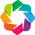

Index(['Country/Region', 'total_investment_million_usd', 'total_gdp',
       'investment_per_gdp_in_window', 'index_vs_eu_average', 'country_key'],
      dtype='object')


In [78]:
import numpy as np
import pandas as pd
import holoviews as hv
from bokeh.models import Span

hv.extension("bokeh")

# --- start from your already-sorted frame ---
df = investments_in_window_sorted.copy()

# Clean types
df["Country/Region"] = df["Country/Region"].astype(str)
df["index_vs_eu_average"] = pd.to_numeric(df["index_vs_eu_average"], errors="coerce")
df = df.dropna(subset=["index_vs_eu_average"])

# Preserve the sorted order on the categorical axis
df["Country/Region"] = pd.Categorical(
    df["Country/Region"],
    categories=list(df["Country/Region"]),
    ordered=True
)



def add_eu_avg_span(plot, element):
    plot.state.add_layout(
        Span(
            location=1.0,          # x = 1.0
            dimension="height",    # vertical line
            line_dash="dashed",
            line_width=1,
            line_alpha=0.8,
            line_color="grey",
        )
    )


renew_invest_bar_df = add_country_key(df, "Country/Region")
print(renew_invest_bar_df.columns)

names_to_drop = ['Italy', 'Latvia', 'Slovak Republic', 'United States']
renew_invest_bar_df = renew_invest_bar_df[~renew_invest_bar_df['Country/Region'].isin(names_to_drop)]
DASHBOARD_COUNTRIES = renew_invest_bar_df['country_key'].tolist()

warn_if_country_keys_differ(
    renew_invest_bar_df,
    emission_change_scatter_df
)
bars = renew_invest_bar_df.hvplot.bar("country_key", "index_vs_eu_average", responsive=True, min_height=600, min_width=800, tools=["hover"])



KEY = "country_key"

scatter = emission_change_scatter_df.hvplot.scatter(
    x='Renewable Percentage',
    y='Emission change (%)',
    c=KEY,
    responsive=True,
    min_height=600
).opts(
    active_tools=["tap", "box_select"],
    selection_alpha=1.0,        # show selection
    nonselection_alpha=0.2, 
)

bars = renew_invest_bar_df.hvplot.bar(
    x=KEY,   # numeric
    y="index_vs_eu_average",                      # categorical key
    tools=["tap", "hover"],
    height=600,
    width=800,
).opts(
    invert_axes=True,                       # horizontal bars
    active_tools=["tap"],       # make tap the active tool
    selection_alpha=1.0,        # show selection
    nonselection_alpha=0.2,     # fade others
    
)


# bars = hv.Bars(
#     df,
#     kdims=["Country/Region"],               # categorical axis MUST be a key dimension
#     vdims=["index_vs_eu_average", "color_centered"],
# ).opts(
#     invert_axes=True,                       # horizontal bars
#     height=600,
#     width=800,
#     tools=["hover"],
#     xlabel="Index vs EU average (investment/GDP)",
#     ylabel="",
#     title=(
#         "Renewable RD&D investment per GDP index\n"
#         f"{start_window_year}–{latest_year} (EU average = 1)"
#     ),
#     color=hv.dim("color_centered"),
#     cmap="RdYlGn",
#     clim=(cmin, cmax),
#     colorbar=True,
#     colorbar_opts={"title": "Index vs EU average (lower = worse, higher = better)"},
#     show_grid=True,
#     hooks=[add_eu_avg_span],
# )

# #bars

# bars = df


In [ ]:
import holoviews as hv
import hvplot.pandas  # noqa: F401
from holoviews import opts
from bokeh.models import BoxSelectTool, LassoSelectTool, TapTool, HoverTool
import panel as pn
pn.extension(comms="vscode")   # if you’re in VS Code notebooks; otherwise pn.extension()
from bokeh.plotting import figure
from bokeh.transform import cumsum
import panel as pn
import pandas as pd
import math

import math
import pandas as pd
from bokeh.plotting import figure
from bokeh.transform import cumsum



def _human_money(x):
    # simple helper for readable numbers (optional)
    x = float(x)
    ax = abs(x)
    if ax >= 1e12: return f"{x/1e12:.2f}T"
    if ax >= 1e9:  return f"{x/1e9:.2f}B"
    if ax >= 1e6:  return f"{x/1e6:.2f}M"
    if ax >= 1e3:  return f"{x/1e3:.2f}K"
    return f"{x:.0f}"

def bokeh_pie(df, value_col, label_col="group", title="Pie", height=350, width=350, donut=False):
    df = df.copy()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce").fillna(0.0)

    total = float(df[value_col].sum())
    df["pct"] = (df[value_col] / total) if total else 0.0
    df["angle"] = df["pct"] * 2 * math.pi
    df["pct_str"] = (df["pct"] * 100).map(lambda v: f"{v:.1f}%")
    df["val_human"] = df[value_col].map(_human_money)

    if "color" not in df.columns:
        # enough distinct colors for 2 slices (you can extend if needed)
        df["color"] = ["#7598CF", "#F0BC9E"][:len(df)]

    p = figure(
        height=height,
        width=width,
        title=title,
        toolbar_location=None,
        tools="hover",
        tooltips=[
            ("Group", f"@{label_col}"),
            ("Value", f"@{value_col}{{0,0}}"),
            ("Value (short)", "@val_human"),
            ("Share", "@pct_str"),
        ],
        x_range=(-0.5, 0.5),
    )

    wedge_kwargs = {}
    if donut:
        wedge_kwargs["inner_radius"] = 0.22

    p.wedge(
        x=0, y=0, radius=0.4,
        start_angle=cumsum("angle", include_zero=True),
        end_angle=cumsum("angle"),
        line_color="white",
        fill_color="color",
        legend_field=label_col,
        source=df,
        **wedge_kwargs,
    )

    p.axis.visible = False
    p.grid.visible = False
    p.legend.location = "top_left"
    return p


hv.extension("bokeh")
KEY = "country_key"

print("hvPlot:", hvplot.__version__)
print("HoloViews:", hv.__version__)

# (optional but recommended) enforce numeric axes
emission_change_scatter_df["Renewable Percentage"] = pd.to_numeric(emission_change_scatter_df["Renewable Percentage"], errors="coerce")
emission_change_scatter_df["Emission change (%)"] = pd.to_numeric(emission_change_scatter_df["Emission change (%)"], errors="coerce")
emission_change_scatter_df = emission_change_scatter_df.dropna(subset=["Renewable Percentage", "Emission change (%)"])

gdp_2023 = (
    gdp_population_content
    .loc[lambda df: df["Series Name"] == "GDP (current US$)"]
    .rename(columns={"Country Name": "Country/Region"})
    .pipe(add_country_key, "Country/Region")
    .loc[lambda df: df["country_key"].isin(DASHBOARD_COUNTRIES)]
    .dropna(subset=["Year"])
    .assign(Year=lambda df: df["Year"].astype(int))
    .loc[lambda df: df["Year"] == 2023]
    .copy()
)

invest_pie_df.rename(columns={
    "Cumulative_since_2000_Renewable": "Renewable",
    "Cumulative_since_2000_FossilFuel": "Fossil Fuel",
}, inplace=True)



warn_if_country_keys_differ(
    renew_invest_bar_df,
    gdp_2023,
)

warn_if_country_keys_differ(
    renew_invest_bar_df,
    invest_pie_df,
)


bar_df = renew_invest_bar_df[[KEY, "index_vs_eu_average"]].dropna().copy()
bar_df["color_centered"] = bar_df["index_vs_eu_average"]
print(bar_df.columns)
bars = hv.Bars(
    bar_df,
    kdims=[KEY],
    vdims=["index_vs_eu_average", "color_centered"],
).opts(
    invert_axes=True,
    tools=["tap", "hover"],
    active_tools=["tap"],
    selection_alpha=1.0,
    nonselection_alpha=0.2,
    responsive=True,
    xlabel="Index vs EU average (investment/GDP)",
    ylabel="",
    title=(
         "Renewable RD&D investment per GDP index\n"
         f"{start_window_year}–{latest_year} (EU average = 1)"
    ),
    color=hv.dim("color_centered"),
    cmap="RdYlGn",
    clim=(0, 2),
    colorbar=True,
    colorbar_opts={"title": "Index vs EU average (lower = worse, higher = better)"},
    show_grid=True,
    hooks=[add_eu_avg_span],   
)





box2d = BoxSelectTool(dimensions="both")
print(emission_change_scatter_df.columns)
emission_change_scatter = emission_change_scatter_df.merge(
    gdp_2023[["country_key", "Value"]].rename(columns={"Value": "GDP"}),
    on="country_key",
    how="left",
)

emission_change_scatter_color = emission_change_scatter.merge(
    bar_df[["country_key", "color_centered"]],
    on="country_key",
    how="left",
)

print("Merged scatter df with GDP:")
print(emission_change_scatter_color.head())
points = hv.Points(
    emission_change_scatter_color,
    kdims=["Renewable Percentage", "Emission change (%)"],  # 2D selection
    vdims=[KEY, "GDP", "color_centered"],
).opts(
    tools=["box_select", "lasso_select", "tap", "hover"],
    active_tools=["box_select"],
    selection_alpha=1.0,
    nonselection_alpha=0.2,
    responsive=True,
    hover_tooltips=[
            ("Country", f"@{KEY}"),
            ("Renewable %", "@{Renewable Percentage}{0.0}"),
            ("Emission change %", "@{Emission change (%)}{0.0}"),
        ],
    size=hv.dim("GDP") / 3e10,
    color=hv.dim("color_centered"),
    cmap="RdYlGn",
    clim=(0, 2),
    height=600,
)

df = emission_change_scatter_color.dropna(
    subset=["Renewable Percentage", "Emission change (%)"]
)

# Compute linear fit
x = df["Renewable Percentage"].to_numpy()
y = df["Emission change (%)"].to_numpy()

m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = m * x_line + b

trend = hv.Curve(
    (x_line, y_line),
    kdims=["Renewable Percentage"],
    vdims=["Emission change (%)"],
).opts(
    line_width=2,
    line_dash="dashed",
    color="black",
)

ls = hv.link_selections.instance(index_cols=[KEY])

linked_points = ls(points)   # don't call .cols(2) on a single plot
linked_bars   = ls(bars)
# 3) Overlay trend on the points plot (outside ls)
points_with_trend = linked_points * trend

# 4) Layout points+trend next to linked bars
linked = (points_with_trend + linked_bars).cols(2)

expr = ls.param.selection_expr

@pn.depends(ls.param.selection_expr)
def pie_views(expr):
    try:
        ds_gdp = hv.Dataset(gdp_2023, kdims=[KEY])
        ds_inv = hv.Dataset(invest_pie_df, kdims=[KEY])

        if expr is None:
            sel_gdp = gdp_2023
            sel_inv = invest_pie_df
            title = "No selection → all"
        else:
            sel_gdp = ds_gdp.select(expr).data
            sel_inv = ds_inv.select(expr).data
            title = f"Selected countries: {len(sel_gdp)}" if len(sel_gdp) else "Empty selection"

        def selected_vs_not(all_df, sel_df, col, out_col):
            all_total = float(pd.to_numeric(all_df[col], errors="coerce").sum(skipna=True))
            sel_total = float(pd.to_numeric(sel_df[col], errors="coerce").sum(skipna=True)) if len(sel_df) else 0.0
            return pd.DataFrame({
                "group": ["Selected", "Not selected"],
                out_col: [sel_total, max(all_total - sel_total, 0.0)],
            })

        gdp_pie_df = selected_vs_not(gdp_2023, sel_gdp, "Value", "value")
        ren_pie_df = selected_vs_not(invest_pie_df, sel_inv, "Renewable", "value")
        fos_pie_df = selected_vs_not(invest_pie_df, sel_inv, "Fossil Fuel", "value")

        gdp_pie = bokeh_pie(gdp_pie_df, value_col="value", title="GDP")
        ren_pie = bokeh_pie(ren_pie_df, value_col="value", title="Renewable Investment")
        fos_pie = bokeh_pie(fos_pie_df, value_col="value", title="Fossil Fuel Investment")

        return pn.Column(
            pn.pane.Markdown(f"### {title}"),
            pn.Row(
                pn.layout.HSpacer(),   # flexible left
                gdp_pie,
                pn.Spacer(width=30),
                ren_pie,
                pn.Spacer(width=30),
                fos_pie,
                pn.layout.HSpacer(),   # flexible right
                sizing_mode="stretch_width",
            )
        )

    except Exception as e:
        return pn.pane.Markdown(f"**Error in pie_views:** `{type(e).__name__}: {e}`")

dashboard = pn.Column(
    pn.pane.Markdown(
    """
    <div style="text-align:center;">
        <h1 style="text-align:center; font-size:48px; margin-top:10px;">Renewable RD&amp;D Influences on Emission Change</h1>
        <h3 style="font-weight:normal; color:gray;">
            Investment composition and GDP context (2000–2023)
        </h3>
    </div>
    """,
    sizing_mode="stretch_width",
    ),   
)



# dashboard.append(

#     pn.Column(pn.Row(pn.Spacer(width=30),linked,pn.Spacer(width=30)), pie_views,pn.Spacer(width=30))   # ← no list
# )

# dashboard.show() # or .servable() if using with `panel serve`

text = pn.pane.Markdown(
        """
        <div style="font-size:18px; line-height:1.5;">
        <b>How to read this dashboard</b><br>

        • The <b>scatter plot</b> shows the relationship between renewable energy RD&amp;D investment
        and emission changes from 2000–2023. Point size reflects GDP, and the trend line indicates
        that higher renewable investment is associated with lower emissions.<br><br>

        • The <b>bar chart</b> compares renewable investment intensity relative to the EU average.
        Green bars indicate higher-than-average investment, while red bars indicate lower investment.<br><br>

        • The <b>pie charts</b> summarize GDP, renewable investment, and fossil fuel investment for
        selected countries compared to the rest.
        </div>
        """,
        sizing_mode="stretch_width",
    )
    



dashboard.append(
    pn.Row(
        pn.Column(
            pn.Row(pn.Spacer(width=100),
                text
            ),
            pn.Spacer(height=20),
            linked_bars),
        pn.Column(
            points_with_trend,
            pie_views),
    pn.Spacer(height=30)
    )
)

dashboard.show()
    



hvPlot: 0.12.2
HoloViews: 1.22.1
Index(['country_key', 'index_vs_eu_average', 'color_centered'], dtype='object')
Index(['Country/Region', 'Year', 'Renewable Percentage',
       'Fossile Fuel Percentage', 'Emission change (%)', 'country_key'],
      dtype='object')
Merged scatter df with GDP:
  Country/Region  Year  Renewable Percentage  Fossile Fuel Percentage  \
0      Australia  2023             42.901186                57.098814   
1        Austria  2023             93.835330                 6.164670   
2        Belgium  2023             74.209476                25.790524   
3         Canada  2023             30.663033                69.336967   
4        Denmark  2023             86.779936                13.220064   

   Emission change (%) country_key           GDP  color_centered  
0           -12.994965   Australia  1.728057e+12        0.536139  
1           -34.872218     Austria  5.116852e+11        1.093182  
2           -50.313620     Belgium  6.446553e+11        0.624960  
